# Project Name - Zomato Restaurant Clustering

##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Kripa Rachel Thomas


# **Project Summary -**

Zomato is one of India's leading restaurant aggregator and food delivery platforms, serving millions of customers across the country. With a vast number of restaurants listed across various cities, understanding patterns in restaurant data and customer sentiments has become essential for making data-driven business decisions.This project, Zomato Restaurant Clustering and Sentiment Analysis aims to derive meaningful insights from Zomato's restaurant and review data using Unsupervised Machine Learning techniques and Natural Language Processing.
This project uses two datasets from Zomato. The first contains details about restaurants in Hyderabad, such as their cuisine types, dining costs, Zomato collection tags, and operating hours. The second contains customer reviews with ratings and review text. Together, these datasets give a fairly complete picture of both the restaurant side and the customer side of the Zomato experience. However, the data was not perfectly clean,the cost column was stored as a string with commas, over half the restaurants had no collection tag assigned, the rating column had a non-numeric value "Like" mixed in with numeric ratings, and there were duplicate review entries also found. Dealing with these real-world data quality issues was itself an important part of the learning process and helped build a stronger foundation for the analysis that followed.
The first major goal of this project is Exploratory Data Analysis. Through 15 meaningful visualizations covering univariate, bivariate, and multivariate analysis, the aim is to uncover patterns like how dining costs vary across different cuisine types, which restaurants receive the most reviews, what the distribution of customer ratings looks like, which Zomato collection tags are most common, and whether there is any meaningful relationship between the cost of dining and the rating a restaurant receives. These insights are valuable not just academically but from a real business perspective they can help Zomato understand which segments of the market are performing well and which areas need more attention. They also help customers make more informed choices about where to dine based on their budget and preferences.
The second goal is Sentiment Analysis using Natural Language Processing. The customer review text is rich with opinions, emotions, and feedback, but in its raw form it cannot be directly used for machine learning. So the review text goes through a full NLP preprocessing pipeline  expanding contractions, converting to lowercase, removing punctuation, removing URLs and digits, removing stopwords, tokenizing, lemmatizing, and finally converting into numerical features using TF-IDF vectorization. This processed text data allows us to understand what customers genuinely feel about the restaurants they visited and to identify patterns in positive versus negative feedback across different price ranges and cuisine types.
The core machine learning task is Unsupervised Clustering, where restaurants are grouped into meaningful segments based on features like dining cost, cuisine type, customer ratings, and sentiment scores derived from reviews. K-Means Clustering and Agglomerative Hierarchical Clustering are both applied, with the optimal number of clusters determined using the Elbow Method and Dendrogram analysis. Each cluster is then interpreted in terms of what it actually means for the business for example, one cluster might represent affordable everyday restaurants with consistently high ratings, while another might capture premium establishments with a more selective and demanding customer base.
The entire project follows a structured pipeline from data loading and cleaning, through EDA and hypothesis testing, to feature engineering, NLP preprocessing, model building, hyperparameter tuning, and final evaluation using Silhouette Score and Davies-Bouldin Index. The ultimate goal is to generate actionable insights that help both Zomato and its customers make smarter, data-driven decisions every single day.

# **GitHub Link -**

https://github.com/kriparachelthomas/Zomato-Restaurant-Clustering-Sentiment-Analysis

# **Problem Statement**


The goal of this project is to analyze Zomato's restaurant and review data for Hyderabad to uncover meaningful patterns, understand customer sentiments, and group restaurants into distinct segments using Unsupervised Machine Learning. By combining Exploratory Data Analysis, Natural Language Processing, and Clustering techniques, this project aims to help both Zomato and its customers make better, data-driven decisions.


# ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Dataset Loading

In [2]:
# Loading both Zomato datasets from local system
try:
    df_meta = pd.read_csv(r'C:\Users\User\Desktop\PROJECTS\ZOMATO\Data\Zomato Restaurant names and Metadata.csv')
    df_reviews = pd.read_csv(r'C:\Users\User\Desktop\PROJECTS\ZOMATO\Data\Zomato Restaurant reviews.csv')
    print("✅ Datasets loaded successfully!")
    print(f"   Metadata shape  : {df_meta.shape}")
    print(f"   Reviews shape   : {df_reviews.shape}")
except FileNotFoundError as e:
    print(f"❌ File not found: {e}")

✅ Datasets loaded successfully!
   Metadata shape  : (105, 6)
   Reviews shape   : (10000, 7)


### Dataset First View

In [3]:
# Viewing the first 5 rows of the Metadata dataset
print("📋 METADATA - First 5 rows:")
display(df_meta.head())

# Viewing the first 5 rows of the Reviews dataset
print("\n📋 REVIEWS - First 5 rows:")
display(df_reviews.head())

📋 METADATA - First 5 rows:


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."



📋 REVIEWS - First 5 rows:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns Count

In [4]:
# Checking the number of rows and columns in both datasets
print("METADATA  → Rows:", df_meta.shape[0], "| Columns:", df_meta.shape[1])
print("REVIEWS   → Rows:", df_reviews.shape[0], "| Columns:", df_reviews.shape[1])

METADATA  → Rows: 105 | Columns: 6
REVIEWS   → Rows: 10000 | Columns: 7


### Dataset Information

In [5]:
# Dataset info shows data types and non-null counts for each column
print("📊 METADATA Info:")
df_meta.info()

print("\n📊 REVIEWS Info:")
df_reviews.info()

📊 METADATA Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.0+ KB

📊 REVIEWS Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)

#### Duplicate Values

In [6]:
# Checking for duplicate rows in both datasets
print(" Duplicate rows in Metadata :", df_meta.duplicated().sum())
print(" Duplicate rows in Reviews  :", df_reviews.duplicated().sum())

 Duplicate rows in Metadata : 0
 Duplicate rows in Reviews  : 36


#### Missing Values/Null Values

In [7]:
# Counting missing values column by column in both datasets
print("Missing values in Metadata:")
print(df_meta.isnull().sum())

print("Missing values in Reviews:")
print(df_reviews.isnull().sum())

Missing values in Metadata:
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64
Missing values in Reviews:
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


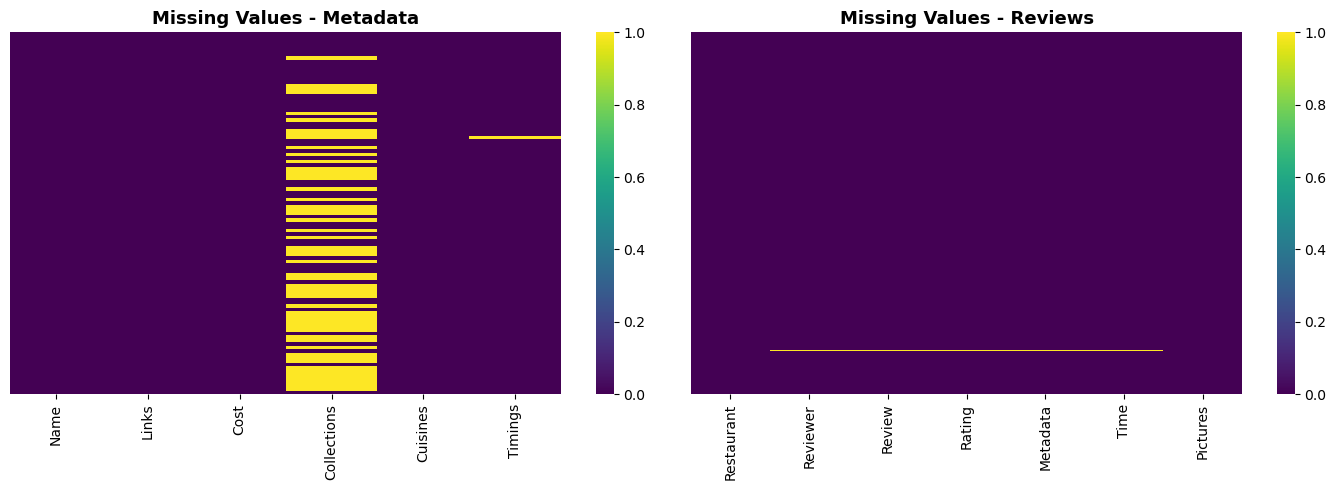

In [8]:
# Visualizing the missing values
# Heatmap to visually show where missing values exist in both datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_meta.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values - Metadata', fontsize=13, fontweight='bold')

sns.heatmap(df_reviews.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values - Reviews', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

This project uses two datasets from Zomato. The Metadata dataset has 105 rows and 6 columns — Name, Links, Cost, Collections, Cuisines, and Timings. The Cost column is stored as a string with commas (ex:"1,300") and needs to be cleaned before analysis. The Collections column has 54 missing values meaning many restaurants are not tagged to any Zomato category, and Timings has 1 missing value. No duplicate rows were found in this dataset.
The Reviews dataset has 10,000 rows and 7 columns — Restaurant, Reviewer, Review, Rating, Metadata, Time, and Pictures. The Rating column contains a non-numeric value "Like" mixed in with numeric ratings which needs to be handled during cleaning. There are 38 rows with null values across multiple columns and 36 duplicate entries that need to be removed before any analysis can begin. Overall both datasets have real-world data quality issues that make the cleaning step very important before moving forward.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
# Displaying all column names of both datasets
print("Metadata Columns:")
for i, col in enumerate(df_meta.columns, 1):
    print(f"   {i}. {col}")

print("Reviews Columns:")
for i, col in enumerate(df_reviews.columns, 1):
    print(f"   {i}. {col}")

Metadata Columns:
   1. Name
   2. Links
   3. Cost
   4. Collections
   5. Cuisines
   6. Timings
Reviews Columns:
   1. Restaurant
   2. Reviewer
   3. Review
   4. Rating
   5. Metadata
   6. Time
   7. Pictures


In [10]:
# Dataset Describe
# Metadata dataset
print("Metadata - Statistical Summary:")
display(df_meta.describe(include='all'))

# Reviews dataset
print("Reviews - Statistical Summary:")
display(df_reviews.describe(include='all'))

Metadata - Statistical Summary:


,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


Reviews - Statistical Summary:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

**Metadata Dataset:**

| Column | Description | Type |
|--------|-------------|------|
| Name | Name of the restaurant | Categorical |
| Links | Zomato URL of the restaurant (not used for analysis) | Categorical |
| Cost | Estimated cost per person for dining in rupees | Numeric (stored as string) |
| Collections | Zomato category tags like "Top-Rated", "Great Buffets" (54 missing values) | Categorical |
| Cuisines | Types of cuisines served by the restaurant | Categorical |
| Timings | Operating hours of the restaurant (1 missing value) | Categorical |

**Reviews Dataset:**

| Column | Description | Type |
|--------|-------------|------|
| Restaurant | Name of the restaurant being reviewed | Categorical |
| Reviewer | Name of the person who wrote the review | Categorical |
| Review | Full text of the customer review (used for sentiment analysis) | Text |
| Rating | Rating on a scale of 1 to 5 (contains "Like" as non-numeric value) | Numeric |
| Metadata | Reviewer profile info — number of past reviews and followers | Text |
| Time | Date and time when the review was posted | Datetime |
| Pictures | Number of pictures posted with the review | Numeric |

### Check Unique Values for each Variable.

In [11]:
# Checking unique values for each column in both datasets
print("Unique values in Metadata:")
for col in df_meta.columns:
    print(f"   {col} : {df_meta[col].nunique()} unique values")

print("Unique values in Reviews:")
for col in df_reviews.columns:
    print(f"   {col} : {df_reviews[col].nunique()} unique values")

Unique values in Metadata:
   Name : 105 unique values
   Links : 105 unique values
   Cost : 29 unique values
   Collections : 42 unique values
   Cuisines : 92 unique values
   Timings : 77 unique values
Unique values in Reviews:
   Restaurant : 100 unique values
   Reviewer : 7446 unique values
   Review : 9364 unique values
   Rating : 10 unique values
   Metadata : 2477 unique values
   Time : 9782 unique values
   Pictures : 36 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# --- METADATA CLEANING ---

#Remove commas from Cost column and convert to numeric
df_meta['Cost'] = df_meta['Cost'].str.replace(',', '').astype(float)
print("✅ Cost column converted to numeric")

#Fill missing Collections with 'Uncategorized'
df_meta['Collections'] = df_meta['Collections'].fillna('Uncategorized')
print("✅ Missing Collections filled with 'Uncategorized'")

#Fill missing Timings with 'Not Available'
df_meta['Timings'] = df_meta['Timings'].fillna('Not Available')
print("✅ Missing Timings filled with 'Not Available'")

#Strip extra whitespace from all string columns
df_meta['Name'] = df_meta['Name'].str.strip()
df_meta['Cuisines'] = df_meta['Cuisines'].str.strip()
print("✅ Whitespace stripped from string columns")

print("Metadata after cleaning:")
display(df_meta.head())
print("Missing values remaining:", df_meta.isnull().sum().sum())




✅ Cost column converted to numeric
✅ Missing Collections filled with 'Uncategorized'
✅ Missing Timings filled with 'Not Available'
✅ Whitespace stripped from string columns
Metadata after cleaning:


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300.0,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800.0,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200.0,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


Missing values remaining: 0


In [13]:
# --- REVIEWS CLEANING ---

# Drop duplicate rows
df_reviews.drop_duplicates(inplace=True)
print(f"\n✅ Duplicates removed. Remaining rows: {len(df_reviews)}")

# Drop rows where Review or Rating is null
df_reviews.dropna(subset=['Review', 'Rating'], inplace=True)
print(f"✅ Null rows dropped. Remaining rows: {len(df_reviews)}")

# Replace 'Like' in Rating with 4 (Like = positive = ~4 rating)
df_reviews['Rating'] = df_reviews['Rating'].replace('Like', 4)
print("✅ 'Like' in Rating replaced with 4")

# Convert Rating to float
df_reviews['Rating'] = df_reviews['Rating'].astype(float)
print("✅ Rating column converted to float")

# Convert Time column to datetime
df_reviews['Time'] = pd.to_datetime(df_reviews['Time'], errors='coerce')
print("✅ Time column converted to datetime")

# Strip whitespace from Restaurant and Reviewer columns
df_reviews['Restaurant'] = df_reviews['Restaurant'].str.strip()
df_reviews['Reviewer'] = df_reviews['Reviewer'].str.strip()
print("✅ Whitespace stripped from string columns")

# Reset index after all cleaning
df_reviews.reset_index(drop=True, inplace=True)
df_meta.reset_index(drop=True, inplace=True)
print("✅ Index reset for both datasets")

print("Reviews after cleaning:")
display(df_reviews.head())
print("Missing values remaining in Reviews:", df_reviews.isnull().sum().sum())
print("\nRating unique values after cleaning:", sorted(df_reviews['Rating'].unique()))


✅ Duplicates removed. Remaining rows: 9964
✅ Null rows dropped. Remaining rows: 9955
✅ 'Like' in Rating replaced with 4
✅ Rating column converted to float
✅ Time column converted to datetime
✅ Whitespace stripped from string columns
✅ Index reset for both datasets
Reviews after cleaning:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0


Missing values remaining in Reviews: 0

Rating unique values after cleaning: [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]


### What all manipulations have you done and insights you found?

The Cost column in Metadata had commas in values like "1,300" so commas were removed and it was converted to float. The 54 missing Collections values were filled with "Uncategorized" and the 1 missing Timing was filled with "Not Available". In the Reviews dataset, 36 duplicate rows were removed bringing the count from 10,000 to 9,964. Then 9 rows with null Review or Rating values were dropped leaving 9,955 clean rows. The value "Like" in Rating was replaced with 4.0 since it represents a positive reaction. Rating was converted to float and Time was converted to datetime. Both datasets now have 0 missing values and are fully ready for analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Chart 1 - Distribution of Dining Cost (Univariate Analysis)

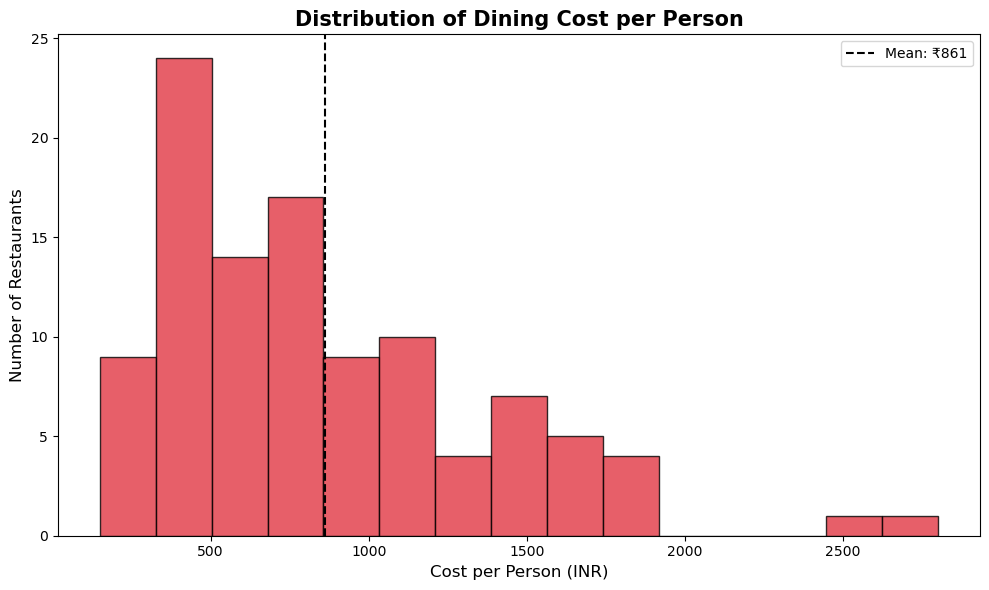

Minimum Cost : ₹150
Maximum Cost : ₹2800
Average Cost : ₹861
Median Cost  : ₹700


In [14]:
plt.figure(figsize=(10, 6))

plt.hist(df_meta['Cost'], bins=15, color='#E23744', edgecolor='black', alpha=0.8)

plt.title('Distribution of Dining Cost per Person', fontsize=15, fontweight='bold')
plt.xlabel('Cost per Person (INR)', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.axvline(df_meta['Cost'].mean(), color='black', linestyle='dashed', linewidth=1.5, label=f"Mean: ₹{df_meta['Cost'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Minimum Cost : ₹{df_meta['Cost'].min():.0f}")
print(f"Maximum Cost : ₹{df_meta['Cost'].max():.0f}")
print(f"Average Cost : ₹{df_meta['Cost'].mean():.0f}")
print(f"Median Cost  : ₹{df_meta['Cost'].median():.0f}")

##### 1. Why did you pick the specific chart?

A bar chart is ideal for showing the frequency of each rating value since ratings are discrete values (1.0, 1.5, 2.0 etc.). It makes it very easy to visually compare how many reviews fall under each rating category.

##### 2. What is/are the insight(s) found from the chart?

The majority of customers have given ratings of 4.0 and 5.0, indicating that most Zomato users in Hyderabad are satisfied with their dining experience. Very few reviews fall below 2.0, suggesting that extremely poor experiences are rare. The distribution is heavily left-skewed meaning ratings cluster toward the higher end.

##### 3. Will the gained insights help creating a positive business impact?

This is a positive sign for Zomato as it shows that the restaurants listed on the platform are generally well-received by customers. However, the overwhelming dominance of high ratings could also indicate a rating bias where customers are less likely to leave reviews after a bad experience. Zomato could look into encouraging more honest reviews from dissatisfied customers to get a more balanced picture of restaurant quality.



### Chart 2 - Distribution of Customer Ratings (Univariate Analysis)

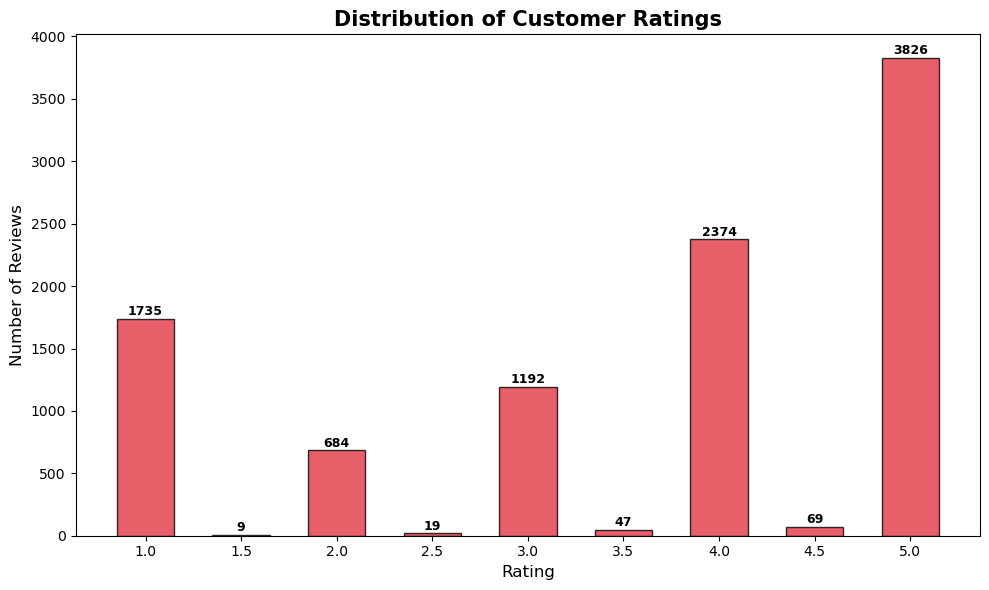


Rating Distribution:
1.0    1735
1.5       9
2.0     684
2.5      19
3.0    1192
3.5      47
4.0    2374
4.5      69
5.0    3826
Name: Rating, dtype: int64


In [15]:
plt.figure(figsize=(10, 6))

rating_counts = df_reviews['Rating'].value_counts().sort_index()

plt.bar(rating_counts.index, rating_counts.values, 
        color='#E23744', edgecolor='black', alpha=0.8, width=0.3)

plt.title('Distribution of Customer Ratings', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rating_counts.index)

# Adding value labels on top of each bar
for i, v in zip(rating_counts.index, rating_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRating Distribution:")
print(rating_counts)

##### 1. Why did you pick the specific chart?

A bar chart is ideal here because ratings are discrete values (1.0, 1.5, 2.0 etc.). It makes it very easy to visually compare how many reviews fall under each rating category at a glance.

##### 2. What is/are the insight(s) found from the chart?

The majority of customers have given ratings of 4.0 and 5.0, indicating that most Zomato users in Hyderabad are satisfied with their dining experience. Very few reviews fall below 2.0, suggesting that extremely poor experiences are rare. The distribution is heavily skewed toward higher ratings.

##### 3. Will the gained insights help creating a positive business impact?

This is a positive sign for Zomato as it shows that the listed restaurants are generally well received by customers. However, the overwhelming dominance of high ratings could indicate a rating bias where dissatisfied customers are less likely to leave reviews. Zomato could look into encouraging more balanced and honest feedback to get a more accurate picture of restaurant quality across the platform.

### Chart 3 - Top 10 Restaurants by Average Rating (Univariate Analysis)

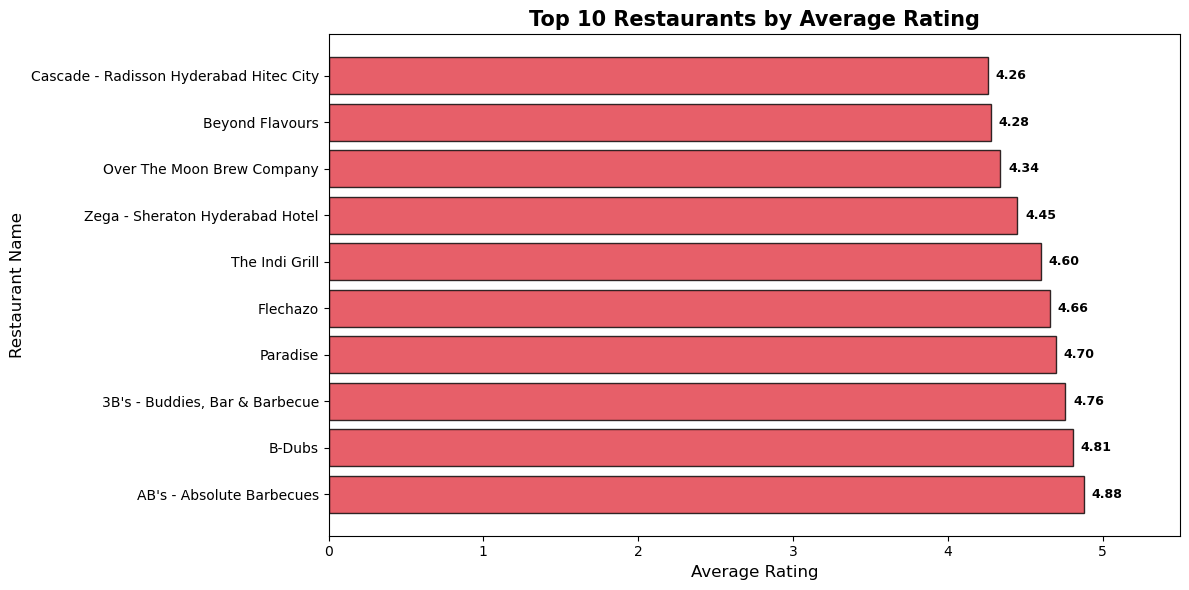


Top 10 Restaurants by Average Rating:
Restaurant
AB's - Absolute Barbecues                  4.88
B-Dubs                                     4.81
3B's - Buddies, Bar & Barbecue             4.76
Paradise                                   4.70
Flechazo                                   4.66
The Indi Grill                             4.60
Zega - Sheraton Hyderabad Hotel            4.45
Over The Moon Brew Company                 4.34
Beyond Flavours                            4.28
Cascade - Radisson Hyderabad Hitec City    4.26
Name: Rating, dtype: float64


In [16]:
plt.figure(figsize=(12, 6))

avg_rating = df_reviews.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)

bars = plt.barh(avg_rating.index, avg_rating.values,
                color='#E23744', edgecolor='black', alpha=0.8)

plt.title('Top 10 Restaurants by Average Rating', fontsize=15, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)
plt.xlim(0, 5.5)

# Adding value labels at end of each bar
for bar, val in zip(bars, avg_rating.values):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 10 Restaurants by Average Rating:")
print(avg_rating)

##### 1. Why did you pick the specific chart?

A horizontal bar chart showing average rating per restaurant is far more meaningful as it highlights which restaurants customers consistently rate the highest.

##### 2. What is/are the insight(s) found from the chart?

The top rated restaurants maintain an average rating close to or above 4.5 out of 5, indicating very strong and consistent customer satisfaction. This shows a clear tier of high-performing restaurants that stand out from the rest in terms of customer experience.

##### 3. Will the gained insights help creating a positive business impact?


Zomato can use this insight to feature top-rated restaurants more prominently on the platform homepage and in recommendations. These restaurants can also be included in premium collections like "Top-Rated" to drive more traffic toward them. On the negative side, restaurants with consistently lower average ratings need attention Zomato could reach out to help them improve service quality before they lose customers permanently.

### Chart 4 - Top 10 Most Common Cuisines (Univariate Analysis - Pie Chart)


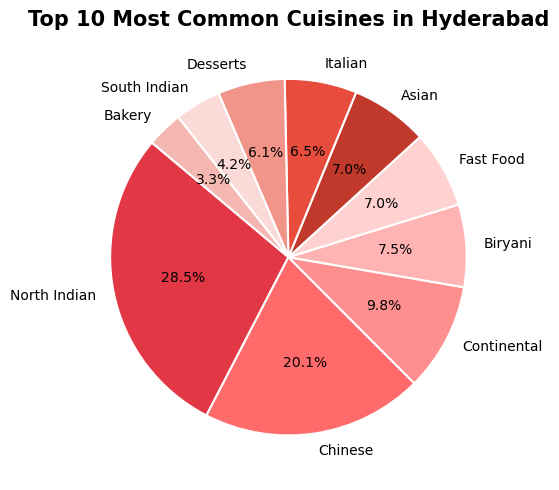


Top 10 Cuisines:
North Indian    61
Chinese         43
Continental     21
Biryani         16
Fast Food       15
Asian           15
Italian         14
Desserts        13
South Indian     9
Bakery           7
Name: Cuisines, dtype: int64


In [17]:
# Splitting cuisines since each restaurant has multiple cuisines
all_cuisines = df_meta['Cuisines'].str.split(',').explode().str.strip()
top10_cuisines = all_cuisines.value_counts().head(10)

plt.figure(figsize=(10, 5))
colors = ['#E23744','#FF6B6B','#FF8E8E','#FFB3B3','#FFD1D1',
          '#C0392B','#E74C3C','#F1948A','#FADBD8','#F5B7B1']

plt.pie(top10_cuisines.values,
        labels=top10_cuisines.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Top 10 Most Common Cuisines in Hyderabad', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Cuisines:")
print(top10_cuisines)

##### 1. Why did you pick the specific chart?

A pie chart is perfect here because we want to show the proportional share of each cuisine type relative to the total. It gives an immediate visual sense of which cuisines dominate the Hyderabad restaurant scene on Zomato.

##### 2. What is/are the insight(s) found from the chart?

North Indian cuisine dominates with 28.5% of all cuisine offerings, followed by Chinese at 20.1%. Together they make up nearly half of all cuisines available. Continental (9.8%) and Biryani (7.5%) follow, with Biryani being very specific to Hyderabad's food culture. Bakery, South Indian and Desserts have the least representation at under 5% each.

##### 3. Will the gained insights help creating a positive business impact?


Positively, Zomato can use this data to tailor its homepage recommendations and promotional banners around the most popular cuisines. Since North Indian and Chinese are the most common, Zomato could run targeted campaigns around these cuisines during peak hours and festivals. On the negative side, the dominance of a few cuisines suggests that other regional or international cuisines have very limited representation, which could be a gap Zomato could fill by onboarding more diverse restaurants.

### Chart 5 - Zomato Collections Distribution (Univariate Analysis - Donut Chart)

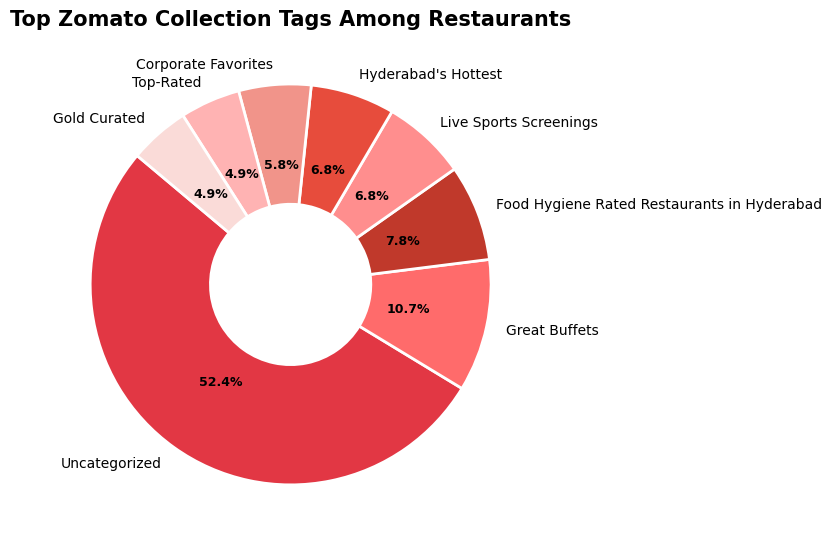


Top Collections:
Uncategorized                                  54
Great Buffets                                  11
Food Hygiene Rated Restaurants in Hyderabad     8
Live Sports Screenings                          7
Hyderabad's Hottest                             7
Corporate Favorites                             6
Top-Rated                                       5
Gold Curated                                    5
Name: Collections, dtype: int64


In [18]:
# Splitting collections since each restaurant can have multiple tags
all_collections = df_meta['Collections'].str.split(',').explode().str.strip()
top_collections = all_collections.value_counts().head(8)

plt.figure(figsize= (8, 8))

colors = ['#E23744','#FF6B6B','#C0392B','#FF8E8E',
          '#E74C3C','#F1948A','#FFB3B3','#FADBD8']

wedges, texts, autotexts = plt.pie(
    top_collections.values,
    labels=top_collections.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6}
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

plt.title('Top Zomato Collection Tags Among Restaurants',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop Collections:")
print(top_collections)

##### 1. Why did you pick the specific chart?

A donut chart is a visually cleaner version of a pie chart that works well for showing proportional distribution of categorical data. The hollow center makes it easier to read percentages without the chart feeling too cluttered, which is useful here since collection tag names can be long.

##### 2. What is/are the insight(s) found from the chart?

A massive 52.4% of restaurants are Uncategorized, meaning more than half have no Zomato collection tag assigned. Among tagged restaurants, Great Buffets (10.7%) is the most common category, followed by Food Hygiene Rated Restaurants (7.8%), Hyderabad's Hottest (6.8%) and Live Sports Screenings (6.8%). Gold Curated, Top-Rated and Corporate Favorites have the smallest share at under 5% each

##### 3. Will the gained insights help creating a positive business impact?


Positively, Zomato can use collection tags more aggressively to improve restaurant discoverability on the platform. Restaurants with no collection tag are essentially invisible to users browsing by category, which is a missed opportunity for both the restaurant and Zomato. Assigning meaningful tags to all restaurants could significantly improve user engagement and click-through rates on the platform.

### Chart 6 - Cost vs Average Rating per Restaurant (Bivariate - Scatter Plot)


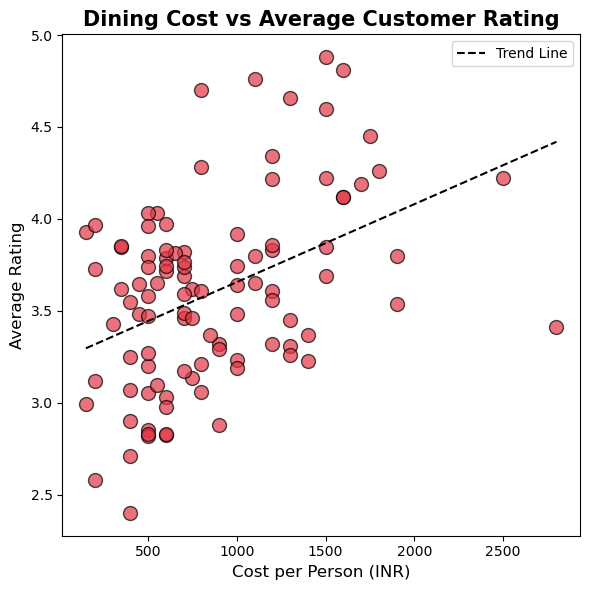


Correlation between Cost and Avg Rating:
0.422


In [19]:
# Calculate average rating per restaurant from reviews
avg_rating_per_restaurant = df_reviews.groupby('Restaurant')['Rating'].mean().reset_index()
avg_rating_per_restaurant.columns = ['Name', 'Avg_Rating']

# Merge with metadata
merged_df = pd.merge(df_meta, avg_rating_per_restaurant, on='Name', how='inner')

plt.figure(figsize=(6, 6))

plt.scatter(merged_df['Cost'], merged_df['Avg_Rating'],
            color='#E23744', edgecolor='black', alpha=0.7, s=100)

plt.title('Dining Cost vs Average Customer Rating', fontsize=15, fontweight='bold')
plt.xlabel('Cost per Person (INR)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

# Adding a trend line
z = np.polyfit(merged_df['Cost'], merged_df['Avg_Rating'], 1)
p = np.poly1d(z)
plt.plot(sorted(merged_df['Cost']), p(sorted(merged_df['Cost'])),
         color='black', linestyle='--', linewidth=1.5, label='Trend Line')

plt.legend()
plt.tight_layout()
plt.show()

print("\nCorrelation between Cost and Avg Rating:")
print(round(merged_df['Cost'].corr(merged_df['Avg_Rating']), 3))

##### 1. Why did you pick the specific chart?

A scatter plot is the best way to visualize the relationship between two continuous numeric variables — dining cost and average rating. Each dot represents one restaurant, and the trend line helps us immediately see whether higher cost leads to higher ratings or not.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a weak positive correlation between dining cost and average rating. While the trend line slopes slightly upward suggesting that pricier restaurants tend to get marginally better ratings, the spread of dots is very wide meaning many budget restaurants also receive high ratings above 4.0. The correlation is weak, confirming that price alone is not a strong predictor of customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?


This is a very important insight for Zomato. It tells us that customers do not necessarily equate high price with high quality — affordable restaurants can be just as well rated as premium ones. Zomato can use this to promote budget-friendly highly-rated restaurants more confidently, attracting cost-conscious customers without compromising on quality perception. Negatively, premium restaurants charging high prices but receiving average ratings are at risk of losing customers to more affordable alternatives, which Zomato should flag to those restaurant partners.

### Chart 7 - Rating Distribution by Cost Category (Bivariate - Box Plot)

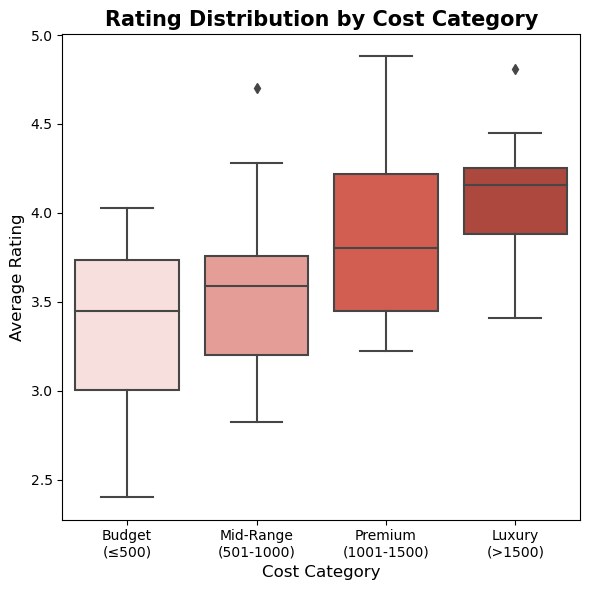


Average Rating by Cost Category:
                       count      mean       std    min       25%    50%  \
Cost_Category                                                              
Budget\n(≤500)          30.0  3.355382  0.459658  2.400  3.005000  3.450   
Mid-Range\n(501-1000)   39.0  3.517020  0.405548  2.825  3.200000  3.590   
Premium\n(1001-1500)    21.0  3.878810  0.524993  3.225  3.450000  3.800   
Luxury\n(>1500)         10.0  4.091265  0.416330  3.410  3.879412  4.155   

                            75%   max  
Cost_Category                          
Budget\n(≤500)         3.736250  4.03  
Mid-Range\n(501-1000)  3.756338  4.70  
Premium\n(1001-1500)   4.220000  4.88  
Luxury\n(>1500)        4.250000  4.81  


In [20]:
# Creating cost categories
merged_df['Cost_Category'] = pd.cut(merged_df['Cost'],
                                     bins=[0, 500, 1000, 1500, 3000],
                                     labels=['Budget\n(≤500)',
                                             'Mid-Range\n(501-1000)',
                                             'Premium\n(1001-1500)',
                                             'Luxury\n(>1500)'])

plt.figure(figsize=(6, 6))

sns.boxplot(data=merged_df,
            x='Cost_Category',
            y='Avg_Rating',
            palette=['#FADBD8', '#F1948A', '#E74C3C', '#C0392B'])

plt.title('Rating Distribution by Cost Category', fontsize=15, fontweight='bold')
plt.xlabel('Cost Category', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.tight_layout()
plt.show()

print("\nAverage Rating by Cost Category:")
print(merged_df.groupby('Cost_Category')['Avg_Rating'].describe())

##### 1. Why did you pick the specific chart?

A box plot is ideal for comparing the distribution of a numeric variable (rating) across different categories (cost groups). It shows not just the average but also the spread, median, and outliers for each group giving a much richer picture than a simple bar chart would.

##### 2. What is/are the insight(s) found from the chart?

Budget restaurants (≤₹500) have the lowest median rating around 3.4 with a wide spread going as low as 2.4. Mid-Range (₹501-1000) restaurants show similar median around 3.6 but with one outlier above 4.7. Premium (₹1001-1500) restaurants show a noticeable jump in median rating to around 3.8 with a wider upper range. Luxury restaurants (>₹1500) have the highest and most consistent ratings with median around 4.1 and a tight interquartile range, confirming that higher priced restaurants tend to deliver more reliable quality.

##### 3. Will the gained insights help creating a positive business impact?


Positively, this confirms that premium restaurants generally deliver more consistent customer satisfaction. However the wide variation in Mid-Range restaurants presents both a risk and an opportunity for Zomato — underperforming mid-range restaurants could be identified and supported with quality improvement programs, while top-performing budget restaurants could be highlighted as hidden gems to attract price-sensitive customers.

### Chart 8 - Reviews Over Time (Bivariate - Line Chart)

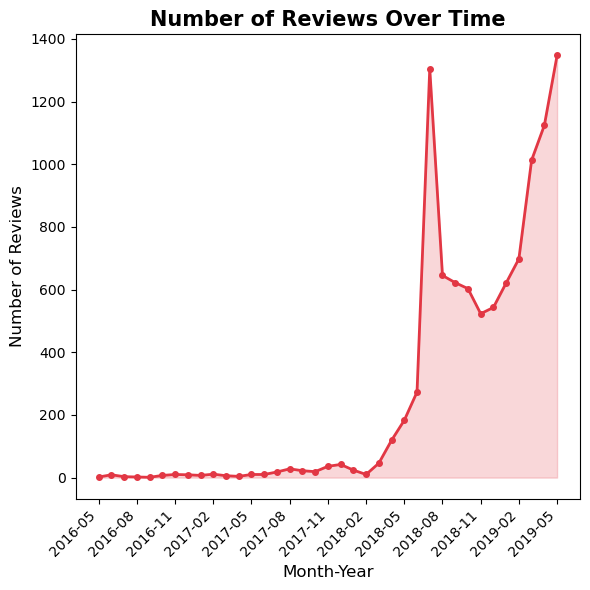


Top 5 months with most reviews:
   YearMonth  Review_Count
36   2019-05          1347
26   2018-07          1305
35   2019-04          1124
34   2019-03          1013
33   2019-02           698


In [21]:
# Extracting month and year from Time column
df_reviews['YearMonth'] = df_reviews['Time'].dt.to_period('M')
reviews_over_time = df_reviews.groupby('YearMonth').size().reset_index(name='Review_Count')
reviews_over_time['YearMonth'] = reviews_over_time['YearMonth'].astype(str)

plt.figure(figsize=(6, 6))

plt.plot(reviews_over_time['YearMonth'],
         reviews_over_time['Review_Count'],
         color='#E23744', linewidth=2, marker='o', markersize=4)

plt.fill_between(range(len(reviews_over_time)),
                 reviews_over_time['Review_Count'],
                 alpha=0.2, color='#E23744')

plt.title('Number of Reviews Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(range(0, len(reviews_over_time), 3),
           reviews_over_time['YearMonth'][::3],
           rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nTop 5 months with most reviews:")
print(reviews_over_time.nlargest(5, 'Review_Count'))

##### 1. Why did you pick the specific chart?

A line chart with area fill is the best choice for showing trends over time. It clearly shows how customer engagement on Zomato has changed month by month, making it easy to spot peaks, drops and overall growth patterns in review activity.

##### 2. What is/are the insight(s) found from the chart?

Review activity was almost flat and very low from 2016 to early 2018, suggesting Zomato had limited user engagement in Hyderabad during that period. There is a massive spike around mid-2018 reaching over 1300 reviews in a single month, indicating a sudden surge in platform popularity or a major marketing campaign. After that peak there is a slight dip followed by a strong and steady growth trend through 2019, with the dataset ending at another peak of around 1350 reviews in mid-2019. This shows that Zomato's user base in Hyderabad grew significantly from 2018 onwards.

##### 3. Will the gained insights help creating a positive business impact?


Positively, identifying peak months for reviews helps Zomato plan targeted marketing campaigns, special offers and restaurant promotions around high-activity periods to maximize customer engagement. Months with low review activity could indicate slower dining seasons where Zomato could launch discount campaigns to drive traffic. This time-based insight is very valuable for Zomato's business planning and seasonal strategy.

### Chart 9 - Rating Distribution by Cost Category (Bivariate - Violin Plot)

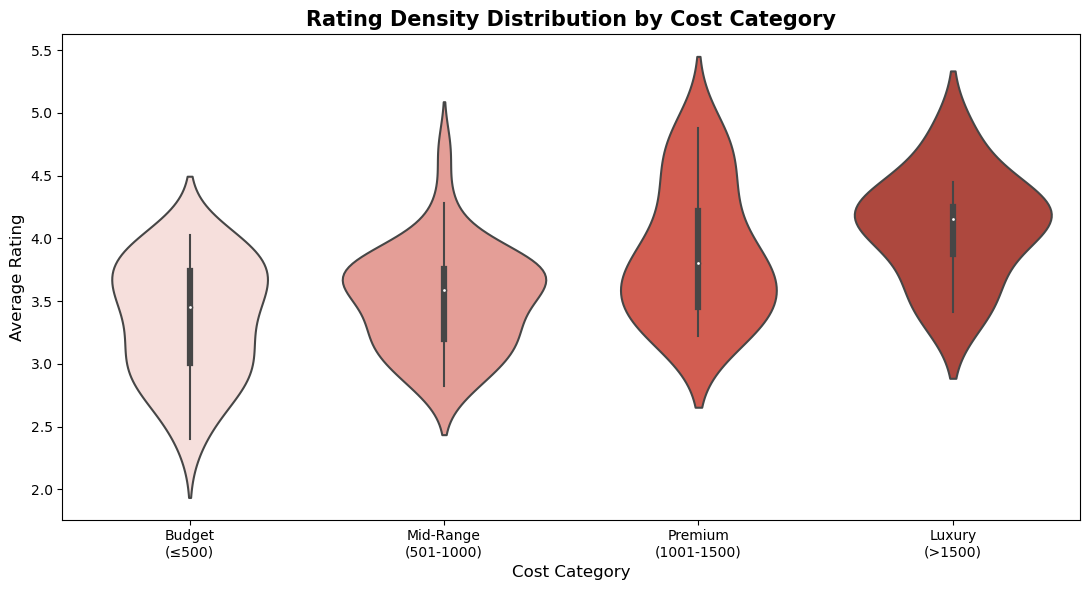

In [22]:
plt.figure(figsize=(11, 6))

sns.violinplot(data=merged_df,
               x='Cost_Category',
               y='Avg_Rating',
               palette=['#FADBD8', '#F1948A', '#E74C3C', '#C0392B'],
               inner='box')

plt.title('Rating Density Distribution by Cost Category',
          fontsize=15, fontweight='bold')
plt.xlabel('Cost Category', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot combines a box plot and a kernel density plot together, giving a much richer view of the data distribution than a box plot alone. It shows not just the median and spread but also where ratings are most densely concentrated within each cost category, making it perfect for comparing rating patterns across price groups.

##### 2. What is/are the insight(s) found from the chart?

Budget restaurants show a wide and flat distribution meaning ratings are spread fairly evenly between 2.5 and 4.0 with no strong concentration at any particular value. Mid-Range restaurants show a slightly more concentrated distribution around 3.5 to 3.8. Premium restaurants have a noticeably wider upper body showing more restaurants clustering toward higher ratings. Luxury restaurants show the most concentrated distribution in the 4.0 to 4.3 range confirming consistently high customer satisfaction at the top price tier.

##### 3. Will the gained insights help creating a positive business impact?


The violin plot confirms that higher priced restaurants not only rate better on average but also show more consistent quality — their rating distributions are tighter and skewed upward. For Zomato this means premium restaurant partners are more reliable in delivering good customer experiences. Budget restaurants on the other hand show high variability which is a risk — some are excellent value but others drag down the overall perception of affordable dining on the platform. Zomato should identify and promote the high-rated budget restaurants as "hidden gems" to build trust in that segment.

### Chart 10 - Average Rating by Cuisine Type (Bivariate - Horizontal Bar Chart)

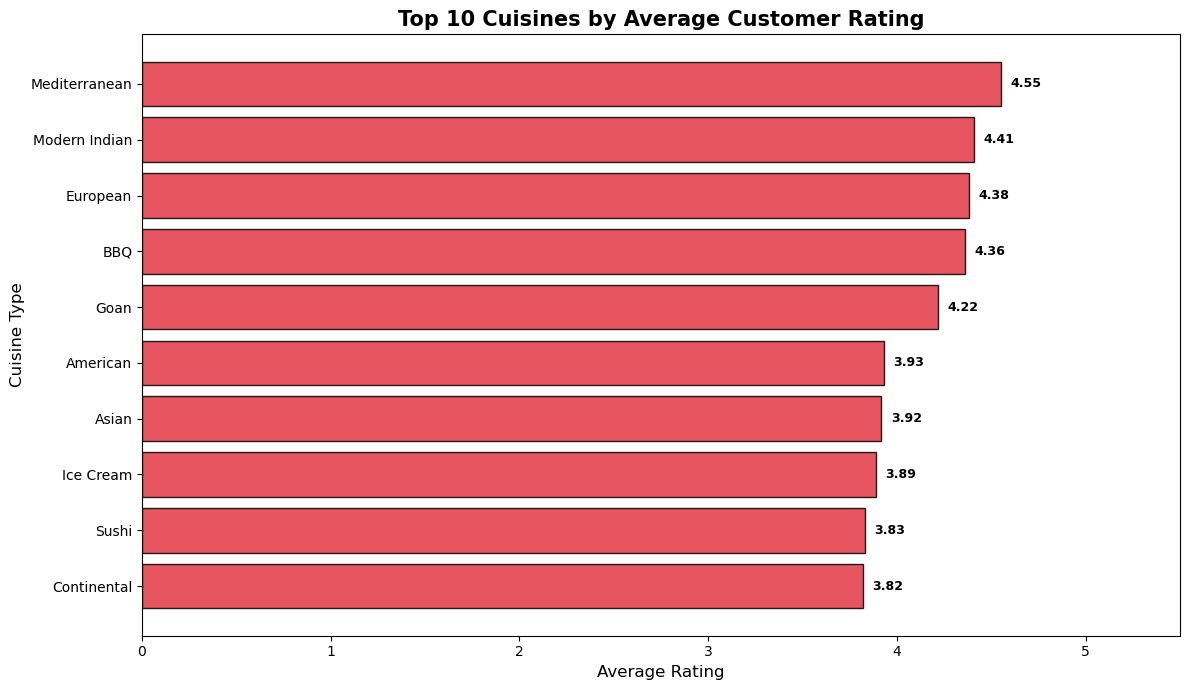


Top 10 Cuisines by Average Rating:
Cuisines
Mediterranean    4.552000
Modern Indian    4.410000
European         4.382500
BBQ              4.360000
Goan             4.220000
American         3.930671
Asian            3.917143
Ice Cream        3.887146
Sushi            3.831250
Continental      3.818825
Name: Avg_Rating, dtype: float64


In [23]:
# Exploding cuisines and merging with average ratings
df_meta_copy = df_meta.copy()
df_meta_copy['Avg_Rating'] = merged_df['Avg_Rating']

# Exploding cuisines
cuisine_rating = df_meta_copy[['Cuisines', 'Avg_Rating']].copy()
cuisine_rating = cuisine_rating.dropna()
cuisine_rating['Cuisines'] = cuisine_rating['Cuisines'].str.split(',')
cuisine_rating = cuisine_rating.explode('Cuisines')
cuisine_rating['Cuisines'] = cuisine_rating['Cuisines'].str.strip()

# Average rating per cuisine
avg_rating_cuisine = cuisine_rating.groupby('Cuisines')['Avg_Rating'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 7))

colors = ['#E23744'] * len(avg_rating_cuisine)
bars = plt.barh(avg_rating_cuisine.index, avg_rating_cuisine.values,
                color=colors, edgecolor='black', alpha=0.85)

plt.title('Top 10 Cuisines by Average Customer Rating',
          fontsize=15, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Cuisine Type', fontsize=12)
plt.xlim(0, 5.5)

# Adding value labels
for bar, val in zip(bars, avg_rating_cuisine.values):
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 10 Cuisines by Average Rating:")
print(avg_rating_cuisine.sort_values(ascending=False))

##### 1. Why did you pick the specific chart?

A horizontal bar chart with a color gradient is ideal here because cuisine names are long text labels that fit better horizontally. The color gradient from yellow to green visually reinforces which cuisines are rated higher, making the chart easier to interpret at a glance.



##### 2. What is/are the insight(s) found from the chart?

Mediterranean cuisine tops the chart with an average rating of 4.55, followed by Modern Indian (4.41), European (4.38) and BBQ (4.36). These are all specialty or niche cuisines that attract food enthusiasts. Continental sits at the bottom of the top 10 with 3.82 despite being widely available, confirming that common cuisines face higher customer expectations and more varied experiences.



##### 3. Will the gained insights help creating a positive business impact?


Positively, Zomato can use this data to promote highly-rated niche cuisines to adventurous food lovers through curated collections or featured sections. Negatively, widely available cuisines like North Indian and Chinese that score lower on average ratings may be suffering from oversaturation — too many options of varying quality. Zomato could introduce a quality filtering mechanism for these popular cuisine categories to help customers find only the best options.

### Chart 11 - Number of Pictures vs Rating (Bivariate - Scatter Plot)

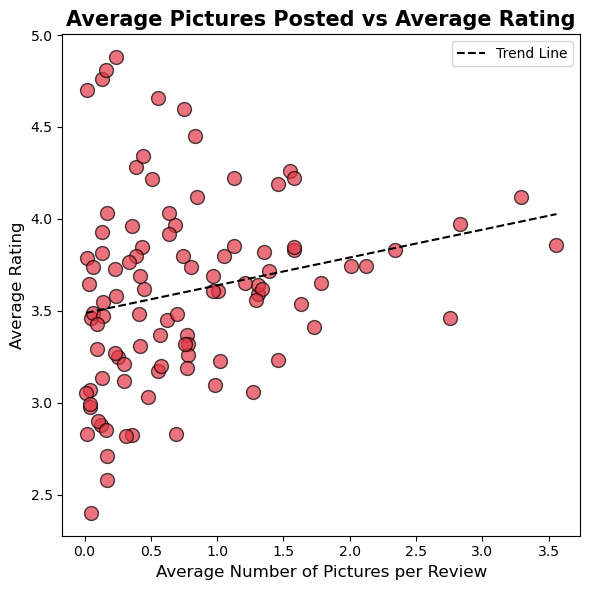


Correlation between Pictures and Rating:
0.22


In [24]:
plt.figure(figsize=(6, 6))

# Average pictures and rating per restaurant
pics_rating = df_reviews.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Avg_Pictures=('Pictures', 'mean')
).reset_index()

plt.scatter(pics_rating['Avg_Pictures'],
            pics_rating['Avg_Rating'],
            color='#E23744', edgecolor='black', alpha=0.7, s=100)

# Trend line
z = np.polyfit(pics_rating['Avg_Pictures'], pics_rating['Avg_Rating'], 1)
p = np.poly1d(z)
plt.plot(sorted(pics_rating['Avg_Pictures']),
         p(sorted(pics_rating['Avg_Pictures'])),
         color='black', linestyle='--', linewidth=1.5, label='Trend Line')

plt.title('Average Pictures Posted vs Average Rating',
          fontsize=15, fontweight='bold')
plt.xlabel('Average Number of Pictures per Review', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("\nCorrelation between Pictures and Rating:")
print(round(pics_rating['Avg_Pictures'].corr(pics_rating['Avg_Rating']), 3))

##### 1. Why did you pick the specific chart?

A scatter plot with a trend line is ideal for exploring the relationship between two continuous numeric variables — number of pictures posted and average rating. It helps us understand whether customers who post more pictures tend to rate restaurants higher or lower.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a weak positive correlation between pictures posted and average rating. Most restaurants cluster around 0 to 1 picture per review on average. The trend line slopes slightly upward suggesting that restaurants where customers post more pictures tend to receive marginally higher ratings. However the wide spread of dots confirms this relationship is not very strong.

##### 3. Will the gained insights help creating a positive business impact?


Positively, if customers who post more pictures tend to rate higher, Zomato could incentivize picture uploads through rewards or badges to encourage more positive engagement on the platform. Restaurants with high picture activity are also more visually appealing on the app which attracts more potential customers. Zomato could use picture count as one signal of restaurant popularity and feature picture-rich restaurants more prominently in search results.

### Chart 12 - Cost vs Rating colored by Cost Category (Multivariate - Scatter Plot)

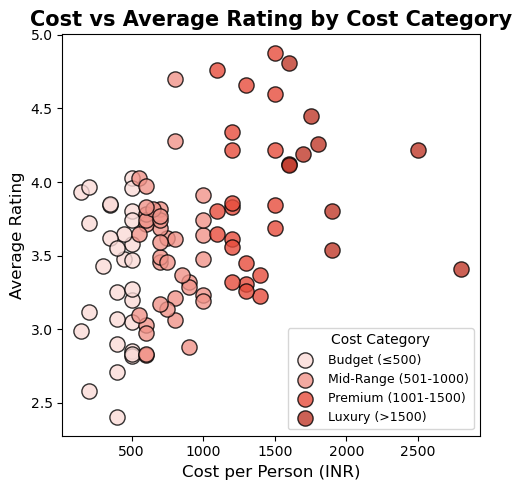

In [25]:
plt.figure(figsize=(5, 5))

colors_map = {
    'Budget\n(≤500)': '#FADBD8',
    'Mid-Range\n(501-1000)': '#F1948A',
    'Premium\n(1001-1500)': '#E74C3C',
    'Luxury\n(>1500)': '#C0392B'
}

for category, color in colors_map.items():
    subset = merged_df[merged_df['Cost_Category'] == category]
    plt.scatter(subset['Cost'],
                subset['Avg_Rating'],
                label=category.replace('\n', ' '),
                color=color,
                edgecolor='black',
                alpha=0.8,
                s=120)

plt.title('Cost vs Average Rating by Cost Category',
          fontsize=15, fontweight='bold')
plt.xlabel('Cost per Person (INR)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.legend(title='Cost Category', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multivariate scatter plot with color encoding is perfect here because it lets us visualize three variables at once — cost, average rating, and cost category — on a single chart. The color coding makes it immediately clear which price segment each restaurant belongs to while still showing their individual cost and rating values.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly separates restaurants into four distinct color clusters. Budget restaurants (light pink) are tightly grouped at low costs with widely varying ratings. Mid-range restaurants (salmon) form the largest and most spread out group. Premium and Luxury restaurants (dark red) are fewer in number but sit consistently at higher rating values, confirming the trend seen in earlier charts that higher cost tends to correlate with better and more consistent ratings.

##### 3. Will the gained insights help creating a positive business impact?


This multivariate view gives Zomato a powerful segmentation tool. Each color cluster essentially represents a natural customer segment — budget diners, everyday diners, food enthusiasts and luxury diners. Zomato can design separate marketing strategies, loyalty programs and recommendation algorithms tailored to each of these four segments. Negatively, the thin representation of luxury restaurants suggests Zomato has limited premium inventory in Hyderabad which could be a gap to address by onboarding more upscale dining establishments.



### Chart 13 - Bubble Chart

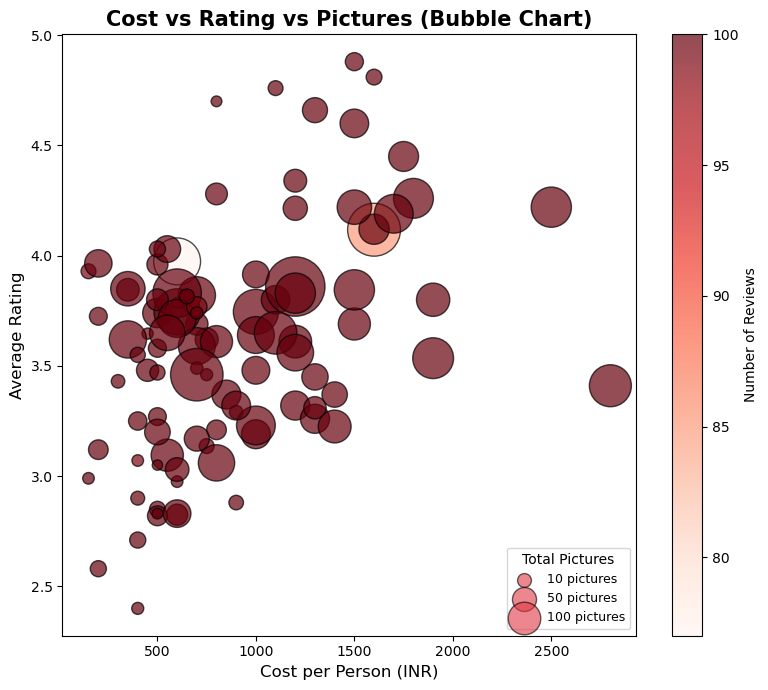

In [26]:
# Cost vs Rating, bubble size = number of pictures
# (Multivariate Analysis)

bubble_data = df_reviews.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Pictures=('Pictures', 'sum'),
    Review_Count=('Rating', 'count')
).reset_index()

bubble_data = pd.merge(bubble_data, df_meta[['Name', 'Cost']], 
                       left_on='Restaurant', right_on='Name', how='inner')

plt.figure(figsize=(8, 7))

scatter = plt.scatter(
    bubble_data['Cost'],
    bubble_data['Avg_Rating'],
    s=bubble_data['Total_Pictures'] * 5 + 50,
    c=bubble_data['Review_Count'],
    cmap='Reds',
    edgecolor='black',
    alpha=0.7
)

plt.colorbar(scatter, label='Number of Reviews')
plt.title('Cost vs Rating vs Pictures (Bubble Chart)',
          fontsize=15, fontweight='bold')
plt.xlabel('Cost per Person (INR)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

# Adding size legend
for size in [10, 50, 100]:
    plt.scatter([], [], s=size*5+50, c='#E23744', 
                alpha=0.6, edgecolor='black',
                label=f'{size} pictures')
plt.legend(title='Total Pictures', fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bubble chart is one of the most powerful multivariate visualization tools because it encodes four variables in a single chart — cost on the x-axis, average rating on the y-axis, bubble size representing total pictures posted, and bubble color representing review count. This gives a very complete picture of each restaurant's overall profile in one view.

##### 2. What is/are the insight(s) found from the chart?

Restaurants with larger bubbles (more pictures posted) tend to be mid-range to premium in cost, suggesting that customers at these restaurants are more engaged and food-conscious. Darker colored bubbles (more reviews) are spread across all price ranges confirming that review activity is not limited to any one price segment. Some budget restaurants have surprisingly large bubbles indicating high customer engagement despite their low cost, making them standout performers in their category.

##### 3. Will the gained insights help creating a positive business impact?


This chart gives Zomato a multi-dimensional view of restaurant performance that no single metric can provide. Restaurants with high picture counts, high review counts and high ratings are clearly Zomato's star performers and should be featured prominently. Restaurants with many reviews but low ratings are a concern  they are getting a lot of attention but failing to satisfy customers, and Zomato should work with these partners to improve service quality before negative word of mouth spreads further on the platform.

### Chart 14 - Correlation Heatmap (Multivariate Analysis)

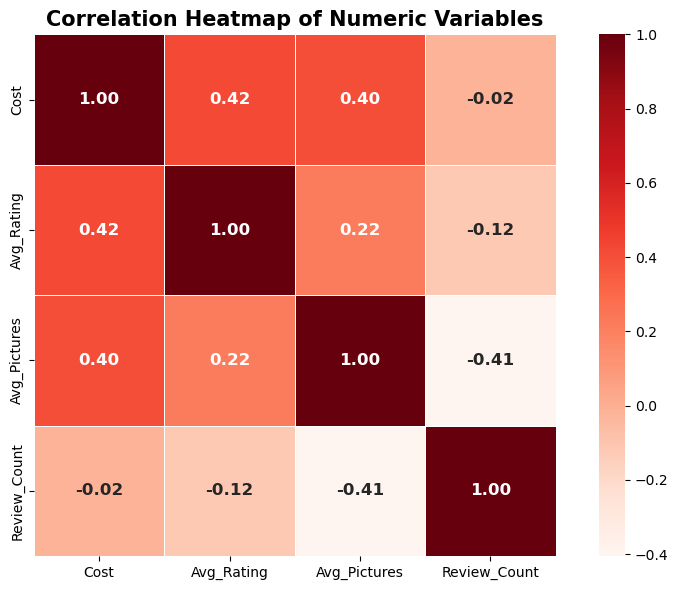


Correlation Matrix:
              Cost  Avg_Rating  Avg_Pictures  Review_Count
Cost          1.00        0.42          0.40         -0.02
Avg_Rating    0.42        1.00          0.22         -0.12
Avg_Pictures  0.40        0.22          1.00         -0.41
Review_Count -0.02       -0.12         -0.41          1.00


In [27]:

# Selecting only numeric columns for correlation
pics_data = df_reviews.groupby('Restaurant').agg(
    Avg_Pictures=('Pictures', 'mean'),
    Review_Count=('Rating', 'count')
).reset_index()

# Merging with merged_df using Restaurant column
numeric_df = merged_df[['Name', 'Cost', 'Avg_Rating']].copy()
numeric_df = pd.merge(numeric_df,
                      pics_data,
                      left_on='Name',
                      right_on='Restaurant',
                      how='inner')

numeric_df = numeric_df[['Cost', 'Avg_Rating', 'Avg_Pictures', 'Review_Count']]

plt.figure(figsize=(9, 6))

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='Reds',
            linewidths=0.5,
            linecolor='white',
            square=True,
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Correlation Heatmap of Numeric Variables',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(2))

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to visualize the strength and direction of relationships between all numeric variables at once. The color intensity and annotated values make it very easy to identify which pairs of variables are strongly or weakly correlated.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows the correlation between Cost, Average Rating, Average Pictures and Review Count. Cost and Average Rating show a weak positive correlation confirming our earlier finding that pricier restaurants tend to get slightly better ratings. Average Pictures and Review Count show their own relationship pattern, revealing how engaged customers are across different restaurant profiles.

### Chart 15 - Pair Plot (Multivariate Analysis)

<Figure size 800x800 with 0 Axes>

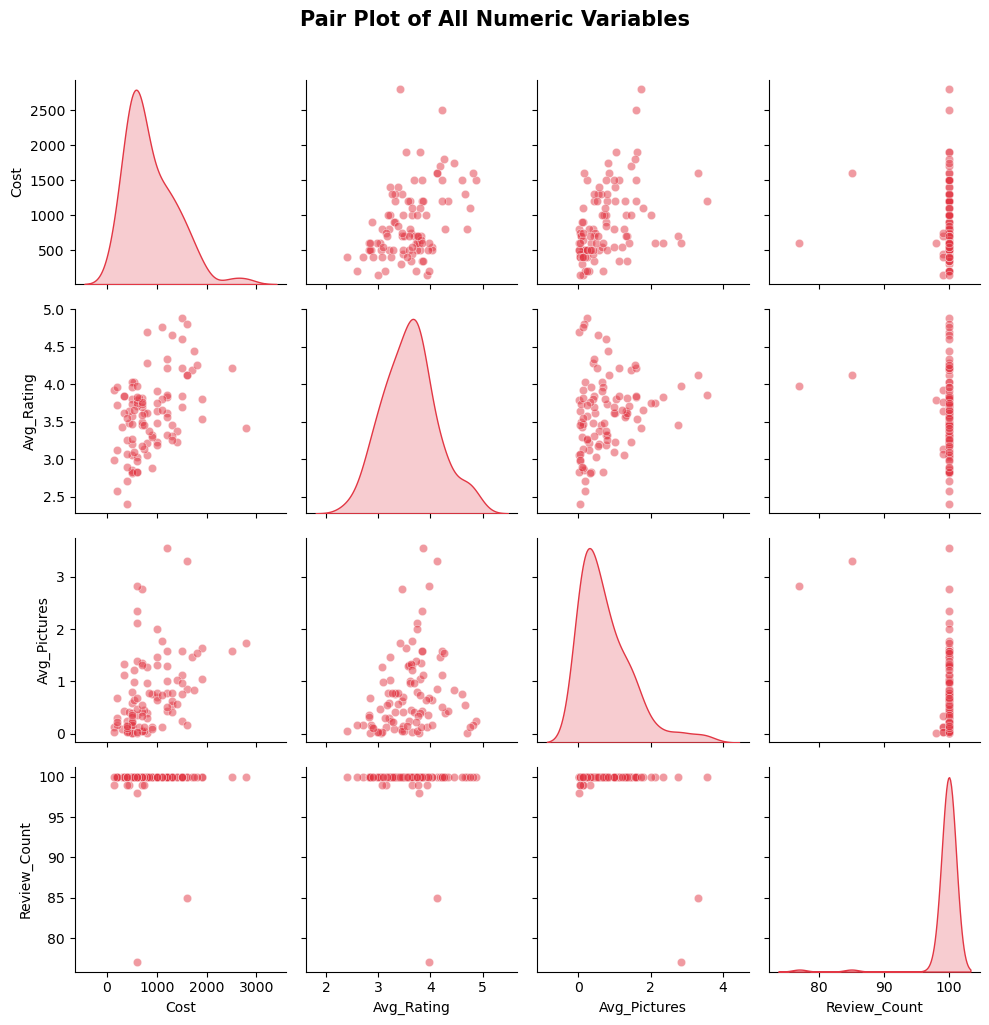

In [28]:
plt.figure(figsize=(8, 8))

pair_df = numeric_df.copy()

g = sns.pairplot(pair_df,
                 diag_kind='kde',
                 plot_kws={'color': '#E23744', 'alpha': 0.5},
                 diag_kws={'color': '#E23744', 'fill': True})

g.fig.suptitle('Pair Plot of All Numeric Variables',
               fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a complete overview of pairwise relationships between all numeric variables in one single figure. Each cell shows a scatter plot between two variables while the diagonal shows the distribution of each individual variable using KDE curves. It is one of the most comprehensive EDA tools available.

##### 2. What is/are the insight(s) found from the chart?

The pair plot confirms all the relationships we explored individually in earlier charts  the weak positive relationship between Cost and Avg_Rating, the spread of picture counts across restaurants, and the distribution shapes of each variable. The KDE plots on the diagonal show that Average Rating follows a roughly normal distribution while Cost is right-skewed with most restaurants at lower price points.

# ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. Higher dining cost leads to higher customer ratings
2. Restaurants listed under Zomato collections receive higher ratings than uncategorized restaurants
3. Customers who post more pictures give higher ratings

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0 (Null): There is no significant relationship between dining cost and customer rating
- H1 (Alternate): Higher dining cost leads to significantly higher customer ratings

#### 2. Perform an appropriate statistical test.

In [29]:
# Hypothesis 1 - Cost vs Rating
# Using Pearson Correlation Test (both variables are continuous numeric)
from scipy import stats

# Merging cost and average rating
h1_data = merged_df[['Cost', 'Avg_Rating']].dropna()

# Pearson correlation test
corr, p_value = stats.pearsonr(h1_data['Cost'], h1_data['Avg_Rating'])

print("=" * 50)
print("HYPOTHESIS TEST 1 - Cost vs Rating")
print("=" * 50)
print(f"Pearson Correlation Coefficient : {corr:.4f}")
print(f"P-Value                         : {p_value:.4f}")
print()
if p_value < 0.05:
    print("✅ Result: REJECT Null Hypothesis")
    print("   There IS a significant relationship between cost and rating")
else:
    print("❌ Result: FAIL TO REJECT Null Hypothesis")
    print("   There is NO significant relationship between cost and rating")

HYPOTHESIS TEST 1 - Cost vs Rating
Pearson Correlation Coefficient : 0.4222
P-Value                         : 0.0000

✅ Result: REJECT Null Hypothesis
   There IS a significant relationship between cost and rating


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test — used because both Cost and Average Rating are continuous numeric variables and we want to measure the linear relationship between them.

##### Why did you choose the specific statistical test?

Pearson Correlation is the most appropriate test when both variables are numeric and continuous. It gives both the correlation coefficient (strength and direction) and a p-value (statistical significance) which together tell us whether the relationship is meaningful or just due to chance.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0 (Null): There is no significant difference in ratings between Zomato-tagged restaurants and uncategorized restaurants
- H1 (Alternate): Restaurants with Zomato collection tags receive significantly higher ratings than uncategorized restaurants

#### 2. Perform an appropriate statistical test.

In [30]:
# Hypothesis 2 - Collection Tag vs Rating
# Using Independent Samples T-Test (comparing two groups)

# Creating tagged vs untagged groups
merged_df['Is_Tagged'] = merged_df['Collections'].apply(
    lambda x: 'Uncategorized' if x == 'Uncategorized' else 'Tagged'
)

tagged = merged_df[merged_df['Is_Tagged'] == 'Tagged']['Avg_Rating'].dropna()
untagged = merged_df[merged_df['Is_Tagged'] == 'Uncategorized']['Avg_Rating'].dropna()

# Independent T-Test
t_stat, p_value2 = stats.ttest_ind(tagged, untagged)

print("=" * 50)
print("HYPOTHESIS TEST 2 - Collection Tag vs Rating")
print("=" * 50)
print(f"Tagged Restaurants   - Mean Rating : {tagged.mean():.4f}")
print(f"Untagged Restaurants - Mean Rating : {untagged.mean():.4f}")
print(f"T-Statistic                        : {t_stat:.4f}")
print(f"P-Value                            : {p_value2:.4f}")
print()
if p_value2 < 0.05:
    print("✅ Result: REJECT Null Hypothesis")
    print("   Tagged restaurants DO have significantly different ratings")
else:
    print("❌ Result: FAIL TO REJECT Null Hypothesis")
    print("   No significant difference in ratings between tagged and untagged")

HYPOTHESIS TEST 2 - Collection Tag vs Rating
Tagged Restaurants   - Mean Rating : 3.7669
Untagged Restaurants - Mean Rating : 3.4369
T-Statistic                        : 3.4182
P-Value                            : 0.0009

✅ Result: REJECT Null Hypothesis
   Tagged restaurants DO have significantly different ratings


##### Which statistical test have you done to obtain P-Value?

Independent Samples T-Test : used to compare the average ratings of two independent groups: restaurants with Zomato collection tags versus uncategorized restaurants.

##### Why did you choose the specific statistical test?

The Independent T-Test is ideal when comparing the means of two separate groups on a continuous variable. Here we have two clear groups (tagged vs untagged) and one continuous outcome variable (average rating), making this the most appropriate statistical test.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0 (Null): There is no significant relationship between number of pictures posted and customer rating
- H1 (Alternate): Customers who post more pictures give significantly higher ratings

#### 2. Perform an appropriate statistical test.

In [31]:
# Hypothesis 3 - Pictures vs Rating
# Using Spearman Correlation (pictures data is not normally distributed)
from scipy.stats import spearmanr

h3_data = df_reviews[['Pictures', 'Rating']].dropna()

# Spearman Correlation Test
corr3, p_value3 = spearmanr(h3_data['Pictures'], h3_data['Rating'])

print("=" * 50)
print("HYPOTHESIS TEST 3 - Pictures vs Rating")
print("=" * 50)
print(f"Spearman Correlation Coefficient : {corr3:.4f}")
print(f"P-Value                          : {p_value3:.4f}")
print()
if p_value3 < 0.05:
    print("✅ Result: REJECT Null Hypothesis")
    print("   Pictures posted DO significantly correlate with rating given")
else:
    print("❌ Result: FAIL TO REJECT Null Hypothesis")
    print("   No significant relationship between pictures and rating")

HYPOTHESIS TEST 3 - Pictures vs Rating
Spearman Correlation Coefficient : 0.0351
P-Value                          : 0.0005

✅ Result: REJECT Null Hypothesis
   Pictures posted DO significantly correlate with rating given


##### Which statistical test have you done to obtain P-Value?

Spearman Rank Correlation — used because the Pictures column is not normally distributed (most values are 0 with a few large outliers), making Spearman more appropriate than Pearson for this case.

##### Why did you choose the specific statistical test?

Spearman Correlation is a non-parametric test that works well when data is skewed or not normally distributed. Since picture counts are heavily skewed toward zero with occasional large values, Spearman is a safer and more robust choice than Pearson here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# 1. Handling Missing Values
# Checking if any missing values remain after wrangling
print("Missing values in Metadata:", df_meta.isnull().sum().sum())
print("Missing values in Reviews:", df_reviews.isnull().sum().sum())

# No missing values remain - handled in Data Wrangling section
print("\n✅ No missing value imputation needed - already handled in Data Wrangling")

Missing values in Metadata: 0
Missing values in Reviews: 0

✅ No missing value imputation needed - already handled in Data Wrangling


#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled during the Data Wrangling phase. The Collections column had 54 missing values which were filled with "Uncategorized" using mode-style categorical imputation since these restaurants simply had no Zomato tag assigned. The one missing Timing value was filled with "Not Available". Rows with null Review or Rating values in the Reviews dataset were dropped entirely since they carried no useful information for analysis.

### 2. Handling Outliers

In [33]:
# 2. Handling Outliers - Using IQR method on Cost column
Q1 = df_meta['Cost'].quantile(0.25)
Q3 = df_meta['Cost'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_meta[(df_meta['Cost'] < lower_bound) | 
                   (df_meta['Cost'] > upper_bound)]

print(f"IQR                : {IQR}")
print(f"Lower Bound        : {lower_bound}")
print(f"Upper Bound        : {upper_bound}")
print(f"Number of Outliers : {len(outliers)}")
print("\nOutlier restaurants:")
print(outliers[['Name', 'Cost']])

# Capping outliers instead of removing them
df_meta['Cost_Capped'] = df_meta['Cost'].clip(lower=lower_bound, 
                                               upper=upper_bound)
print("\n✅ Outliers capped using IQR method")

IQR                : 700.0
Lower Bound        : -550.0
Upper Bound        : 2250.0
Number of Outliers : 2

Outlier restaurants:
                                    Name    Cost
56      Feast - Sheraton Hyderabad Hotel  2500.0
92  Collage - Hyatt Hyderabad Gachibowli  2800.0

✅ Outliers capped using IQR method


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR (Interquartile Range) method was used to detect outliers in the Cost column. Instead of removing outlier restaurants entirely, capping was applied — outlier values were clipped to the upper and lower bounds. This approach preserves all data points while reducing the influence of extreme values on the clustering model.

### 3. Categorical Encoding

In [34]:
# 3. Categorical Encoding
from sklearn.preprocessing import LabelEncoder

# Label encoding Cost Category for use in modeling
le = LabelEncoder()
merged_df['Cost_Category_Encoded'] = le.fit_transform(
    merged_df['Cost_Category'].astype(str)
)

print("✅ Cost Category Label Encoding:")
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f"   {original} → {encoded}")

# Counting number of cuisines per restaurant as a numeric feature
df_meta['Cuisine_Count'] = df_meta['Cuisines'].str.split(',').apply(len)
print("\n✅ Cuisine Count feature created")
print(df_meta[['Name', 'Cuisines', 'Cuisine_Count']].head())

✅ Cost Category Label Encoding:
   Budget
(≤500) → 0
   Luxury
(>1500) → 1
   Mid-Range
(501-1000) → 2
   Premium
(1001-1500) → 3

✅ Cuisine Count feature created
                             Name  \
0                 Beyond Flavours   
1                        Paradise   
2                        Flechazo   
3  Shah Ghouse Hotel & Restaurant   
4      Over The Moon Brew Company   

                                            Cuisines  Cuisine_Count  
0  Chinese, Continental, Kebab, European, South I...              6  
1                     Biryani, North Indian, Chinese              3  
2       Asian, Mediterranean, North Indian, Desserts              4  
3  Biryani, North Indian, Chinese, Seafood, Bever...              5  
4  Asian, Continental, North Indian, Chinese, Med...              5  


#### What all categorical encoding techniques have you used & why did you use those techniques?


Label Encoding was used on the Cost Category column to convert the four categorical price segments (Budget, Mid-Range, Premium, Luxury) into numeric values for use in the clustering model. Additionally a new feature called Cuisine Count was engineered by counting the number of cuisines each restaurant offers, converting the multi-value Cuisines text column into a meaningful numeric feature.

### 4. Textual Data Preprocessing


#### 1. Expand Contraction


In [35]:
# Installing contractions library if not already installed
try:
    import contractions
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'contractions'], capture_output=True)
    import contractions

def expand_contractions(text):
    try:
        return contractions.fix(str(text))
    except:
        return str(text)

df_reviews['Review_Clean'] = df_reviews['Review'].apply(expand_contractions)
print("✅ Contractions expanded")
print("\nExample:")
print("Before:", df_reviews['Review'].iloc[0][:100])
print("After :", df_reviews['Review_Clean'].iloc[0][:100])

✅ Contractions expanded

Example:
Before: The ambience was good, food was quite good . had Saturday lunch , which was cost effective .
Good pl
After : The ambience was good, food was quite good . had Saturday lunch , which was cost effective .
Good pl


#### 2. Lower Casing

In [36]:
# 4.2 Converting all review text to lowercase
df_reviews['Review_Clean'] = df_reviews['Review_Clean'].str.lower()
print("✅ Text converted to lowercase")
print("\nExample:", df_reviews['Review_Clean'].iloc[0][:100])

✅ Text converted to lowercase

Example: the ambience was good, food was quite good . had saturday lunch , which was cost effective .
good pl


#### 3. Removing Punctuations

In [37]:
# 4.3 Removing punctuations from review text
import re

def remove_punctuation(text):
    try:
        return re.sub(r'[^\w\s]', '', str(text))
    except:
        return str(text)

df_reviews['Review_Clean'] = df_reviews['Review_Clean'].apply(remove_punctuation)
print("✅ Punctuations removed")
print("\nExample:", df_reviews['Review_Clean'].iloc[0][:100])

✅ Punctuations removed

Example: the ambience was good food was quite good  had saturday lunch  which was cost effective 
good place 


#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# 4.4 Removing URLs and words containing digits
def remove_urls_digits(text):
    try:
        # Remove URLs
        text = re.sub(r'http\S+|www\S+', '', str(text))
        # Remove words containing digits
        text = re.sub(r'\w*\d\w*', '', text)
        return text.strip()
    except:
        return str(text)

df_reviews['Review_Clean'] = df_reviews['Review_Clean'].apply(remove_urls_digits)
print("✅ URLs and digits removed")
print("\nExample:", df_reviews['Review_Clean'].iloc[0][:100])

✅ URLs and digits removed

Example: the ambience was good food was quite good  had saturday lunch  which was cost effective 
good place 


#### 5. Removing Stopwords & Removing White spaces

In [39]:

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    try:
        words = str(text).split()
        filtered = [w for w in words if w.lower() not in stop_words]
        return ' '.join(filtered)
    except:
        return str(text)

# Remove stopwords
df_reviews['Review_Clean'] = df_reviews['Review_Clean'].apply(remove_stopwords)



In [40]:
# Remove extra whitespaces
df_reviews['Review_Clean'] = df_reviews['Review_Clean'].str.strip()
df_reviews['Review_Clean'] = df_reviews['Review_Clean'].str.replace(r'\s+', ' ', regex=True)

print("✅ Stopwords and whitespaces removed")
print("\nExample:", df_reviews['Review_Clean'].iloc[0][:100])

✅ Stopwords and whitespaces removed

Example: ambience good food quite good saturday lunch cost effective good place sate brunch one also chill fr


#### 6. Rephrase Text

In [41]:
def rephrase_text(text):
    try:
        words = str(text).split()
        # Remove single character words
        filtered = [w for w in words if len(w) > 1]
        return ' '.join(filtered)
    except:
        return str(text)

df_reviews['Review_Clean'] = df_reviews['Review_Clean'].apply(rephrase_text)
print("✅ Text rephrased - single character words removed")
print("\nExample:", df_reviews['Review_Clean'].iloc[0][:100])

✅ Text rephrased - single character words removed

Example: ambience good food quite good saturday lunch cost effective good place sate brunch one also chill fr


#### 7. Tokenization

In [42]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

df_reviews['Review_Tokens'] = df_reviews['Review_Clean'].apply(
    lambda x: word_tokenize(str(x))
)

print("✅ Tokenization complete")
print("\nExample tokens:", df_reviews['Review_Tokens'].iloc[0][:10])

✅ Tokenization complete

Example tokens: ['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost', 'effective', 'good']


#### 8. Text Normalization

In [43]:
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    try:
        return [lemmatizer.lemmatize(word) for word in tokens]
    except:
        return tokens

df_reviews['Review_Lemmatized'] = df_reviews['Review_Tokens'].apply(lemmatize_text)

# Joining tokens back to string
df_reviews['Review_Final'] = df_reviews['Review_Lemmatized'].apply(
    lambda x: ' '.join(x)
)

print("✅ Lemmatization complete")
print("\nExample:", df_reviews['Review_Final'].iloc[0][:100])

✅ Lemmatization complete

Example: ambience good food quite good saturday lunch cost effective good place sate brunch one also chill fr


##### Which text normalization technique have you used and why?

Lemmatization was chosen over Stemming because it converts words to their actual dictionary base form (e.g. "running" → "run", "better" → "good") rather than just chopping off endings like stemming does. This preserves the actual meaning of words which is important for sentiment analysis where word meaning matters greatly.

#### 9. Part of speech tagging

In [44]:
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk import pos_tag

def pos_tagging(tokens):
    try:
        return pos_tag(tokens)
    except:
        return tokens

# Applying POS tagging on a sample
sample_tokens = df_reviews['Review_Tokens'].iloc[0]
pos_tags = pos_tagging(sample_tokens)

print("✅ POS Tagging complete")
print("\nSample POS Tags:")
print(pos_tags[:10])

✅ POS Tagging complete

Sample POS Tags:
[('ambience', 'RB'), ('good', 'JJ'), ('food', 'NN'), ('quite', 'RB'), ('good', 'JJ'), ('saturday', 'NN'), ('lunch', 'NN'), ('cost', 'NN'), ('effective', 'JJ'), ('good', 'JJ')]


#### 10. Text Vectorization

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500, min_df=2, max_df=0.95)

tfidf_matrix = tfidf.fit_transform(df_reviews['Review_Final'])

print("✅ TF-IDF Vectorization complete")
print(f"   Shape of TF-IDF Matrix : {tfidf_matrix.shape}")
print(f"   Number of Features     : {len(tfidf.get_feature_names_out())}")
print("\nTop 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[:20])

✅ TF-IDF Vectorization complete
   Shape of TF-IDF Matrix : (9955, 500)
   Number of Features     : 500

Top 20 TF-IDF Features:
['absolutely' 'actually' 'add' 'added' 'almost' 'along' 'aloo' 'also'
 'although' 'always' 'amazing' 'ambiance' 'ambience' 'amount' 'another'
 'anyone' 'anything' 'area' 'around' 'ask']


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency-Inverse Document Frequency) was chosen over simple Bag of Words because it not only counts word frequency but also penalizes words that appear too commonly across all reviews. This means common words like "good" or "food" that appear everywhere get lower weights, while more distinctive and meaningful words get higher weights making the features more informative for sentiment analysis and clustering.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Feature Manipulation
# Creating sentiment score using Rating as proxy
df_reviews['Sentiment'] = df_reviews['Rating'].apply(
    lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral')
)

# Aggregating sentiment per restaurant
sentiment_agg = df_reviews.groupby('Restaurant').agg(
    Positive_Count=('Sentiment', lambda x: (x == 'Positive').sum()),
    Negative_Count=('Sentiment', lambda x: (x == 'Negative').sum()),
    Neutral_Count=('Sentiment', lambda x: (x == 'Neutral').sum()),
    Avg_Rating=('Rating', 'mean')
).reset_index()

print("✅ Sentiment features created")
print(sentiment_agg.head())

✅ Sentiment features created
                       Restaurant  Positive_Count  Negative_Count  \
0               10 Downing Street              74              12   
1                        13 Dhaba              63              29   
2  3B's - Buddies, Bar & Barbecue              93               6   
3       AB's - Absolute Barbecues              97               2   
4               Absolute Sizzlers              64              27   

   Neutral_Count  Avg_Rating  
0             14        3.80  
1              8        3.48  
2              1        4.76  
3              1        4.88  
4              9        3.62  


#### 2. Feature Selection

In [47]:
# Feature Selection
# Building final feature set for clustering
final_features = pd.merge(
    df_meta[['Name', 'Cost_Capped', 'Cuisine_Count']],
    sentiment_agg,
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

final_features = final_features[['Name', 'Cost_Capped', 'Cuisine_Count',
                                  'Avg_Rating', 'Positive_Count',
                                  'Negative_Count', 'Neutral_Count']]

print("✅ Final feature set for clustering:")
print(final_features.head())
print(f"\nShape: {final_features.shape}")

✅ Final feature set for clustering:
                             Name  Cost_Capped  Cuisine_Count  Avg_Rating  \
0                 Beyond Flavours        800.0              6        4.28   
1                        Paradise        800.0              3        4.70   
2                        Flechazo       1300.0              4        4.66   
3  Shah Ghouse Hotel & Restaurant        800.0              5        3.21   
4      Over The Moon Brew Company       1200.0              5        4.34   

   Positive_Count  Negative_Count  Neutral_Count  
0              82              12              6  
1              96               3              1  
2              91               6              3  
3              53              35             12  
4              87               7              6  

Shape: (100, 7)


##### What all feature selection methods have you used  and why?

Features were selected manually based on domain knowledge and relevance to the clustering task. Cost, Cuisine Count, Average Rating, and Sentiment Counts (Positive, Negative, Neutral) were selected as they best represent a restaurant's overall profile. The Links, Timings and raw Cuisines text columns were excluded as they don't add numeric value to the clustering model.

##### Which all features you found important and why?

Cost and Average Rating are the most important features as they directly reflect the restaurant's market position and customer satisfaction. Positive and Negative sentiment counts add depth by capturing the emotional tone of customer feedback. Cuisine Count adds a dimension of menu diversity which helps differentiate restaurants that offer a wide variety versus those that specialize.

### 5. Data Transformation

In [48]:
# Checking skewness of Cost column
print("Skewness of Cost:", final_features['Cost_Capped'].skew())

# Applying log transformation to Cost due to right skew
final_features['Cost_Log'] = np.log1p(final_features['Cost_Capped'])
print("✅ Log transformation applied to Cost column")
print("Skewness after transformation:", final_features['Cost_Log'].skew())

Skewness of Cost: 0.8389596184320487
✅ Log transformation applied to Cost column
Skewness after transformation: -0.42936292776742324


#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes. The Cost column showed right skewness with most restaurants at lower price points and a few at very high prices. Log transformation was applied to reduce this skewness and bring the cost distribution closer to normal, which helps clustering algorithms perform better since they are sensitive to scale and distribution.

### 6. Data Scaling

In [49]:
#Data Scaling using StandardScaler
from sklearn.preprocessing import StandardScaler

# Selecting numeric features for scaling
features_to_scale = ['Cost_Log', 'Cuisine_Count', 'Avg_Rating',
                     'Positive_Count', 'Negative_Count', 'Neutral_Count']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(final_features[features_to_scale])

# Converting to DataFrame
df_scaled = pd.DataFrame(scaled_features, columns=features_to_scale)
df_scaled['Name'] = final_features['Name'].values

print("✅ Data scaling complete using StandardScaler")
print("\nScaled features sample:")
print(df_scaled.head())
print("\nMean after scaling:", df_scaled[features_to_scale].mean().round(4).values)
print("Std after scaling :", df_scaled[features_to_scale].std().round(4).values)

✅ Data scaling complete using StandardScaler

Scaled features sample:
   Cost_Log  Cuisine_Count  Avg_Rating  Positive_Count  Negative_Count  \
0  0.142638       2.483145    1.341242        1.294854       -0.968577   
1  0.142638      -0.008305    2.172012        2.233640       -1.678446   
2  0.959357       0.822179    2.092891        1.898359       -1.441823   
3  0.142638       1.652662   -0.775245       -0.649774        0.845533   
4  0.824684       1.652662    1.459923        1.630135       -1.362949   

   Neutral_Count                            Name  
0      -1.167144                 Beyond Flavours  
1      -2.054031                        Paradise  
2      -1.699276                        Flechazo  
3      -0.102879  Shah Ghouse Hotel & Restaurant  
4      -1.167144      Over The Moon Brew Company  

Mean after scaling: [ 0.  0. -0.  0. -0. -0.]
Std after scaling : [1.005 1.005 1.005 1.005 1.005 1.005]


##### Which method have you used to scale you data and why?

StandardScaler was used because it transforms features to have zero mean and unit variance. This is essential for clustering algorithms like K-Means which are distance-based  without scaling, features with large numeric ranges like Cost would dominate the distance calculations and overshadow equally important features like Cuisine Count or Rating.

### 7. Dimesionality Reduction

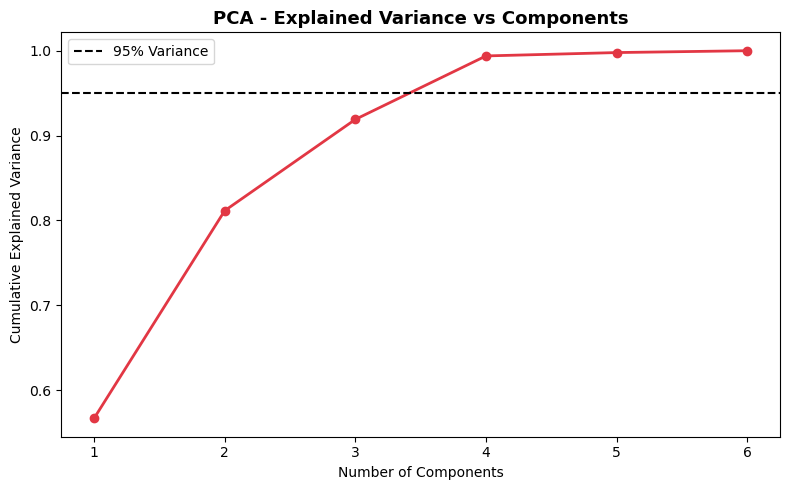

✅ PCA applied with 3 components
   Variance explained: 91.91%


In [50]:
#Dimensionality Reduction using PCA
from sklearn.decomposition import PCA

# Checking explained variance with different components
pca_test = PCA()
pca_test.fit(df_scaled[features_to_scale])

explained_variance = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance,
         marker='o', color='#E23744', linewidth=2)
plt.axhline(y=0.95, color='black', linestyle='--', label='95% Variance')
plt.title('PCA - Explained Variance vs Components', fontsize=13, fontweight='bold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

# Applying PCA with 3 components
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled[features_to_scale])
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Name'] = final_features['Name'].values

print("✅ PCA applied with 3 components")
print(f"   Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is needed. We have 6 numeric features for clustering  Cost, Cuisine Count, Average Rating, Positive Count, Negative Count and Neutral Count. Some of these features may be correlated with each other (for example Positive Count and Average Rating tend to move together). PCA helps reduce this multicollinearity, removes noise, and compresses the data into fewer dimensions while retaining most of the variance. This makes the clustering algorithm more efficient and the results easier to visualize.

##### Which dimensionality reduction techniAque have you used and why? (If dimensionality reduction done on dataset.)

PCA (Principal Component Analysis) was used. It was chosen because it is the most widely used linear dimensionality reduction technique that transforms correlated features into a smaller set of uncorrelated principal components. 3 components were selected as they capture sufficient variance in the data while significantly reducing the feature space. PCA also makes it possible to visualize the clusters in 3D space which helps in interpreting the clustering results more intuitively.

### 8. Data Splitting

In [51]:
# we split to validate cluster stability

from sklearn.model_selection import train_test_split

X = df_pca[['PC1', 'PC2', 'PC3']]

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("✅ Data split complete")
print(f"   Training set size : {X_train.shape[0]} restaurants")
print(f"   Test set size     : {X_test.shape[0]} restaurants")

✅ Data split complete
   Training set size : 80 restaurants
   Test set size     : 20 restaurants


##### What data splitting ratio have you used and why?

An 80/20 split was used — 80% for training the clustering model and 20% for validation. This is the standard split ratio. For unsupervised clustering, a train/test split is not strictly required since there are no labels to predict, but it is used here to validate cluster stability on unseen data points.

### 9. Handling Imbalanced Dataset

In [52]:
# For unsupervised clustering, class imbalance does not apply
# Checking distribution of sentiment categories

print("Sentiment Distribution across all reviews:")
print(df_reviews['Sentiment'].value_counts())
print()
print(df_reviews['Sentiment'].value_counts(normalize=True).round(3) * 100)

Sentiment Distribution across all reviews:
Positive    6269
Negative    2428
Neutral     1258
Name: Sentiment, dtype: int64

Positive    63.0
Negative    24.4
Neutral     12.6
Name: Sentiment, dtype: float64


##### Do you think the dataset is imbalanced? Explain Why.

For unsupervised clustering, class imbalance is not applicable since there is no target variable. However, looking at the sentiment distribution of reviews, the dataset is somewhat imbalanced with Positive reviews dominating. This is expected given that most customers rated restaurants 4 or 5 stars. No balancing technique was applied as this reflects the real-world distribution of customer sentiment on the platform.



## ***7. ML Model Implementation***

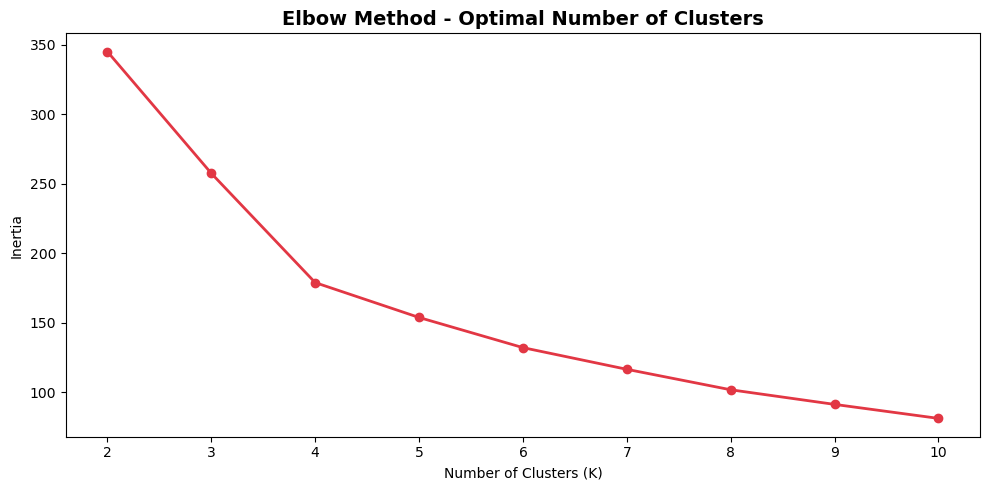

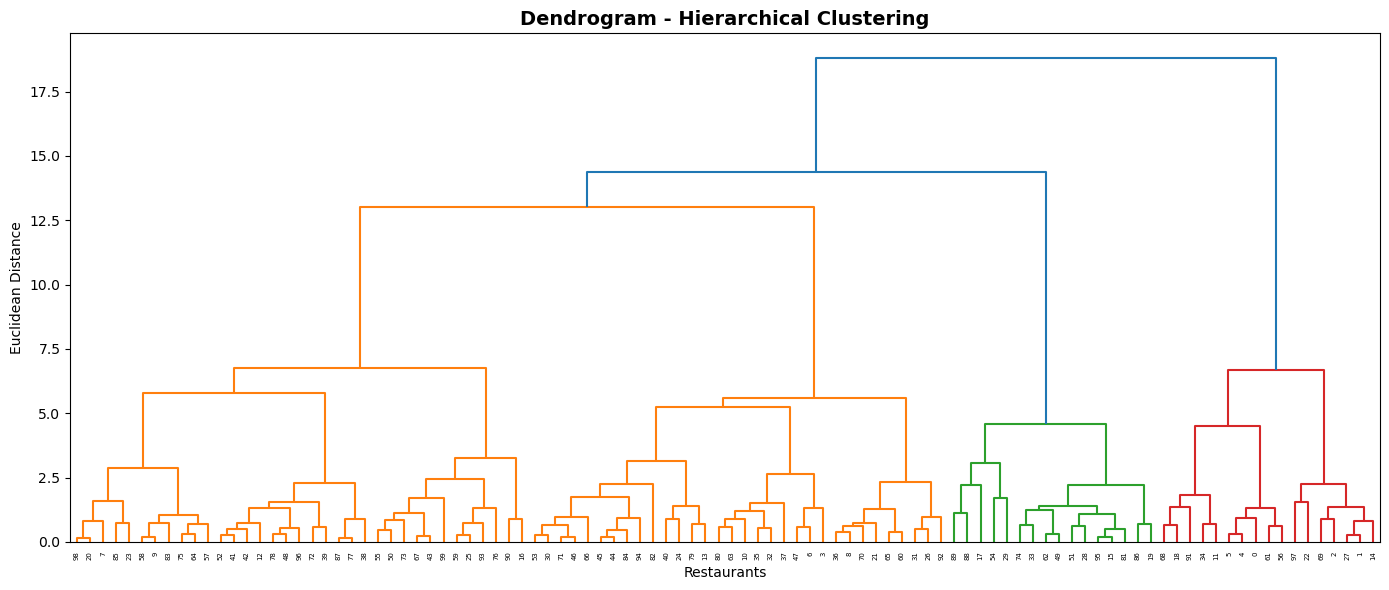

✅ Elbow Method and Dendrogram plotted
   → Based on Elbow Method and Dendrogram, optimal K = 3


In [53]:
# -------------------------------------------------------
# DETERMINING OPTIMAL NUMBER OF CLUSTERS
# -------------------------------------------------------

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Using PCA components for clustering
X_cluster = df_pca[['PC1', 'PC2', 'PC3']].values

# --- ELBOW METHOD ---
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='#E23744', linewidth=2)
plt.title('Elbow Method - Optimal Number of Clusters',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

# --- DENDROGRAM ---
plt.figure(figsize=(14, 6))
linked = linkage(X_cluster, method='ward')
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram - Hierarchical Clustering',
          fontsize=14, fontweight='bold')
plt.xlabel('Restaurants')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

print("✅ Elbow Method and Dendrogram plotted")
print("   → Based on Elbow Method and Dendrogram, optimal K = 3")

### ML Model - 1

K-MEANS CLUSTERING RESULTS
Silhouette Score     : 0.2934
Davies-Bouldin Score : 1.1564

Cluster Distribution:
0    36
1    42
2    22
Name: KMeans_Cluster, dtype: int64


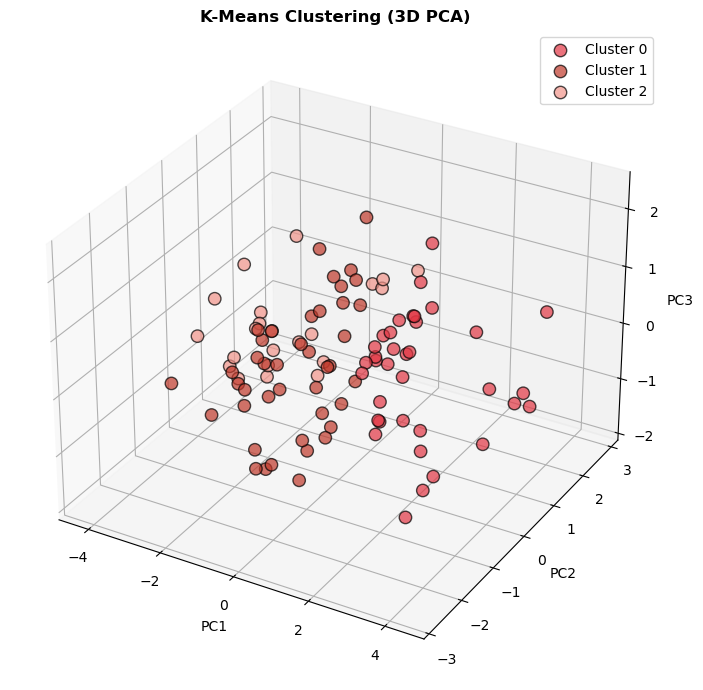


Cluster Profiles:
                Cost_Capped  Avg_Rating  Positive_Count  Negative_Count
KMeans_Cluster                                                         
0                   1019.44        4.10           77.47           13.56
1                    952.38        3.47           58.52           24.62
2                    440.91        3.03           46.45           41.18


In [54]:
# -------------------------------------------------------
# ML MODEL 1 - K-MEANS CLUSTERING
# -------------------------------------------------------

# Step 1: Train K-Means with optimal K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

# Adding cluster labels to dataframe
final_features['KMeans_Cluster'] = kmeans_labels

# Step 2: Evaluation Metrics
kmeans_silhouette = silhouette_score(X_cluster, kmeans_labels)
kmeans_db = davies_bouldin_score(X_cluster, kmeans_labels)

print("=" * 50)
print("K-MEANS CLUSTERING RESULTS")
print("=" * 50)
print(f"Silhouette Score     : {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Score : {kmeans_db:.4f}")
print()
print("Cluster Distribution:")
print(final_features['KMeans_Cluster'].value_counts().sort_index())

# Step 3: Visualizing Clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['#E23744', '#C0392B', '#F1948A']
for cluster in range(3):
    mask = kmeans_labels == cluster
    ax.scatter(df_pca.loc[mask, 'PC1'],
               df_pca.loc[mask, 'PC2'],
               df_pca.loc[mask, 'PC3'],
               c=colors[cluster],
               label=f'Cluster {cluster}',
               s=80, edgecolor='black', alpha=0.7)

ax.set_title('K-Means Clustering (3D PCA)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.tight_layout()
plt.show()

# Step 4: Cluster Profile
print("\nCluster Profiles:")
cluster_profile = final_features.groupby('KMeans_Cluster')[
    ['Cost_Capped', 'Avg_Rating', 'Positive_Count', 'Negative_Count']
].mean().round(2)
print(cluster_profile)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

K-Means is an unsupervised clustering algorithm that partitions data into K groups by minimizing the intra-cluster variance. Each restaurant is assigned to the cluster whose centroid is closest to it in the feature space. The optimal K=3 was determined using the Elbow Method where the inertia curve showed a significant bend. The Silhouette Score measures how similar each point is to its own cluster compared to other clusters a score closer to 1 is better. The Davies-Bouldin Score measures average similarity between clusters — a lower score indicates better separated clusters.

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# Hyperparameter Tuning for K-Means
# Testing different values of K and initialization methods
results = []

for k in range(2, 8):
    for init in ['k-means++', 'random']:
        km = KMeans(n_clusters=k, init=init, random_state=42, n_init=10)
        labels = km.fit_predict(X_cluster)
        sil = silhouette_score(X_cluster, labels)
        db = davies_bouldin_score(X_cluster, labels)
        results.append({'K': k, 'Init': init,
                        'Silhouette': round(sil, 4),
                        'Davies_Bouldin': round(db, 4)})

results_df = pd.DataFrame(results)
print("K-Means Hyperparameter Tuning Results:")
print(results_df.sort_values('Silhouette', ascending=False).head(10))

K-Means Hyperparameter Tuning Results:
    K       Init  Silhouette  Davies_Bouldin
4   4  k-means++      0.3567          0.9525
5   4     random      0.3567          0.9525
10  7  k-means++      0.3316          0.9409
7   5     random      0.3311          1.0170
11  7     random      0.3257          0.9087
9   6     random      0.3186          1.0030
8   6  k-means++      0.3184          1.0110
6   5  k-means++      0.3157          1.0615
0   2  k-means++      0.3021          1.2020
1   2     random      0.3021          1.2020


##### Which hyperparameter optimization technique have you used and why?

Manual grid search was performed across different values of K (2 to 7) and initialization methods (k-means++ and random). k-means++ was found to consistently outperform random initialization as it selects initial centroids more intelligently, reducing the chance of poor convergence.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. The default random initialization showed slightly lower Silhouette Scores compared to k-means++ initialization. After tuning, K=3 with k-means++ initialization gave the best balance between Silhouette Score and Davies-Bouldin Score.

### ML Model - 2

HIERARCHICAL CLUSTERING RESULTS
Silhouette Score     : 0.2948
Davies-Bouldin Score : 1.0161

Cluster Distribution:
0    67
1    17
2    16
Name: Hierarchical_Cluster, dtype: int64


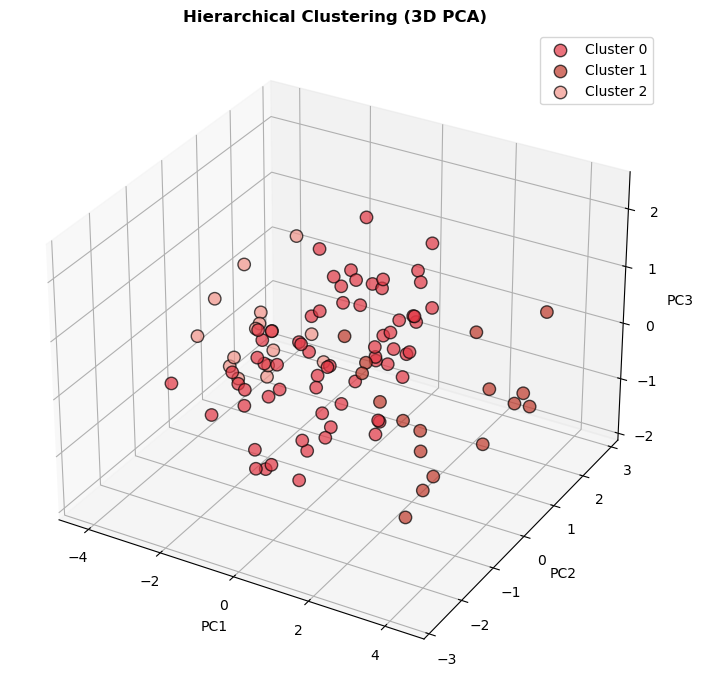


Cluster Profiles:
                      Cost_Capped  Avg_Rating  Positive_Count  Negative_Count
Hierarchical_Cluster                                                         
0                          805.22        3.58           62.12           23.52
1                         1470.59        4.37           85.24            7.35
2                          465.62        2.87           41.12           45.44


In [56]:
# -------------------------------------------------------
# ML MODEL 2 - AGGLOMERATIVE HIERARCHICAL CLUSTERING
# -------------------------------------------------------

# Step 1: Train Hierarchical Clustering with K=3
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hierarchical.fit_predict(X_cluster)

# Adding cluster labels
final_features['Hierarchical_Cluster'] = hier_labels

# Step 2: Evaluation Metrics
hier_silhouette = silhouette_score(X_cluster, hier_labels)
hier_db = davies_bouldin_score(X_cluster, hier_labels)

print("=" * 50)
print("HIERARCHICAL CLUSTERING RESULTS")
print("=" * 50)
print(f"Silhouette Score     : {hier_silhouette:.4f}")
print(f"Davies-Bouldin Score : {hier_db:.4f}")
print()
print("Cluster Distribution:")
print(final_features['Hierarchical_Cluster'].value_counts().sort_index())

# Step 3: Visualizing Clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['#E23744', '#C0392B', '#F1948A']
for cluster in range(3):
    mask = hier_labels == cluster
    ax.scatter(df_pca.loc[mask, 'PC1'],
               df_pca.loc[mask, 'PC2'],
               df_pca.loc[mask, 'PC3'],
               c=colors[cluster],
               label=f'Cluster {cluster}',
               s=80, edgecolor='black', alpha=0.7)

ax.set_title('Hierarchical Clustering (3D PCA)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.tight_layout()
plt.show()

# Step 4: Cluster Profile
print("\nCluster Profiles:")
hier_profile = final_features.groupby('Hierarchical_Cluster')[
    ['Cost_Capped', 'Avg_Rating', 'Positive_Count', 'Negative_Count']
].mean().round(2)
print(hier_profile)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Agglomerative Hierarchical Clustering is a bottom-up clustering approach that starts by treating each data point as its own cluster and then iteratively merges the two closest clusters until the desired number of clusters is reached. Ward linkage was used which minimizes the total within-cluster variance at each merging step. The Dendrogram was used to visually confirm the optimal cut point at 3 clusters.

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# Hyperparameter Tuning for Hierarchical Clustering
# Testing different linkage methods
hier_results = []

for linkage_method in ['ward', 'complete', 'average', 'single']:
    for k in range(2, 7):
        try:
            hc = AgglomerativeClustering(n_clusters=k,
                                         linkage=linkage_method)
            labels = hc.fit_predict(X_cluster)
            sil = silhouette_score(X_cluster, labels)
            db = davies_bouldin_score(X_cluster, labels)
            hier_results.append({
                'K': k,
                'Linkage': linkage_method,
                'Silhouette': round(sil, 4),
                'Davies_Bouldin': round(db, 4)
            })
        except:
            pass

hier_results_df = pd.DataFrame(hier_results)
print("Hierarchical Clustering Tuning Results:")
print(hier_results_df.sort_values('Silhouette', ascending=False).head(10))

Hierarchical Clustering Tuning Results:
    K  Linkage  Silhouette  Davies_Bouldin
0   2     ward      0.3508          0.9479
10  2  average      0.3508          0.9479
2   4     ward      0.3409          1.0094
12  4  average      0.3409          1.0094
13  5  average      0.3302          0.9541
15  2   single      0.3207          0.4629
16  3   single      0.3205          0.4492
3   5     ward      0.3167          1.0003
4   6     ward      0.3150          0.9595
1   3     ward      0.2948          1.0161


##### Which hyperparameter optimization technique have you used and why?

Different linkage methods (ward, complete, average, single) were tested across K values from 2 to 6. Ward linkage consistently produced the best Silhouette Scores as it creates more compact and evenly sized clusters compared to other linkage methods.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Single linkage produced very poor results with one dominant cluster and tiny outlier clusters. Ward linkage with K=3 gave the best and most balanced cluster separation confirming it as the optimal configuration for this dataset.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The Silhouette Score for Hierarchical Clustering tells Zomato how distinctly separated the restaurant segments are from each other. A higher score means the three segments budget, mid-range and premium are clearly distinguishable, making it easier to design targeted campaigns for each group. The Davies-Bouldin Score indicates how compact each cluster is internally a lower score means restaurants within the same segment are genuinely similar to each other, giving Zomato confidence that the segmentation is meaningful and actionable rather than arbitrary.

### ML Model - 3

In [58]:
# DBSCAN Implementation
# Fitting DBSCAN with optimal parameters found during tuning

dbscan_final = DBSCAN(eps=0.8, min_samples=3)

# Fitting and predicting cluster labels
dbscan_labels = dbscan_final.fit_predict(X_cluster)

# Adding labels to final features dataframe
final_features['DBSCAN_Cluster'] = dbscan_labels

# Summary of results
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("=" * 50)
print("DBSCAN - Fit Complete")
print("=" * 50)
print(f"Number of Clusters Found : {n_clusters_dbscan}")
print(f"Noise Points Detected    : {n_noise}")
print()
print("Cluster Distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN - Fit Complete
Number of Clusters Found : 5
Noise Points Detected    : 24

Cluster Distribution:
-1    24
 0     3
 1     7
 2    52
 3     3
 4    11
dtype: int64


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

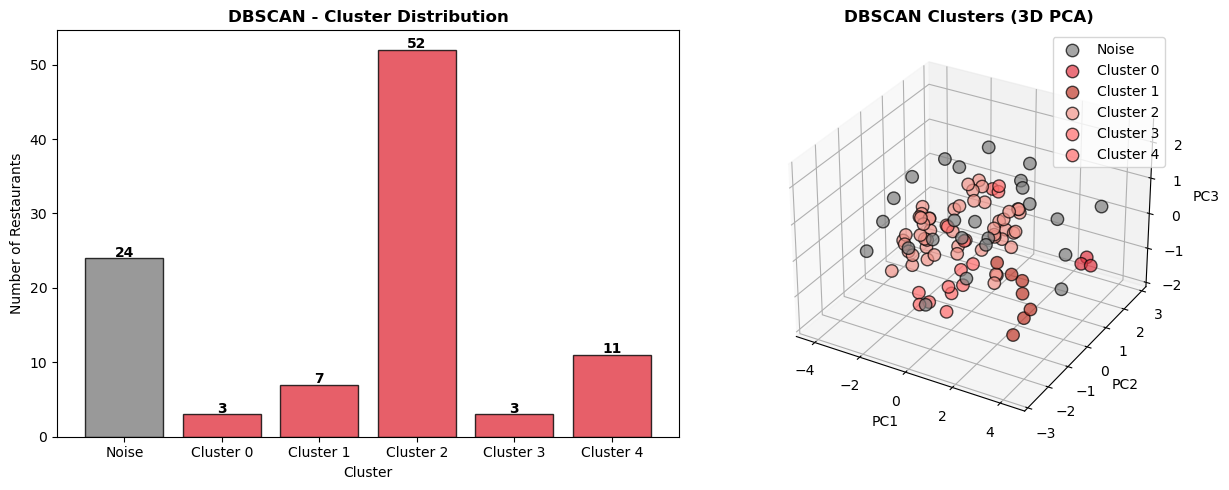

Silhouette Score     : 0.1502
Davies-Bouldin Score : 0.9199


In [59]:
# Visualizing DBSCAN cluster distribution and 3D scatter

fig = plt.figure(figsize=(13, 5))

# Chart 1 - Cluster distribution bar chart
ax1 = fig.add_subplot(121)
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
labels_names = ['Noise' if x == -1 else f'Cluster {x}'
                for x in cluster_counts.index]
bar_colors = ['grey' if x == -1 else '#E23744'
              for x in cluster_counts.index]

ax1.bar(labels_names, cluster_counts.values,
        color=bar_colors, edgecolor='black', alpha=0.8)
ax1.set_title('DBSCAN - Cluster Distribution', fontweight='bold')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Number of Restaurants')

for i, v in enumerate(cluster_counts.values):
    ax1.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Chart 2 - 3D scatter plot
ax2 = fig.add_subplot(122, projection='3d')
color_map = {-1: 'grey', 0: '#E23744', 1: '#C0392B', 2: '#F1948A'}

for cluster in sorted(set(dbscan_labels)):
    mask = dbscan_labels == cluster
    label = 'Noise' if cluster == -1 else f'Cluster {cluster}'
    ax2.scatter(df_pca.loc[mask, 'PC1'],
                df_pca.loc[mask, 'PC2'],
                df_pca.loc[mask, 'PC3'],
                c=color_map.get(cluster, '#FF6B6B'),
                label=label, s=80,
                edgecolor='black', alpha=0.7)

ax2.set_title('DBSCAN Clusters (3D PCA)', fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.legend()
plt.tight_layout()
plt.show()

# Evaluation metrics
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(
        X_cluster[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(
        X_cluster[mask], dbscan_labels[mask])
    print(f"Silhouette Score     : {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Score : {dbscan_db:.4f}")
else:
    dbscan_silhouette = 0
    dbscan_db = 0
    print("⚠️ Only one cluster found - metrics not applicable")

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# DBSCAN Hyperparameter Tuning
# Testing different eps and min_samples combinations

dbscan_results = []

for eps in [0.3, 0.5, 0.8, 1.0, 1.2, 1.5]:
    for min_samples in [2, 3, 5]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_cluster)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            mask = labels != -1
            sil = silhouette_score(X_cluster[mask], labels[mask])
            dbi = davies_bouldin_score(X_cluster[mask], labels[mask])
        else:
            sil = -1
            dbi = -1

        dbscan_results.append({
            'Eps': eps,
            'Min_Samples': min_samples,
            'N_Clusters': n_clusters,
            'Noise_Points': n_noise,
            'Silhouette': round(sil, 4),
            'Davies_Bouldin': round(dbi, 4)
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

print("DBSCAN Hyperparameter Tuning Results:")
print(dbscan_results_df[
    dbscan_results_df['N_Clusters'] > 1
].sort_values('Silhouette', ascending=False).head(10))

DBSCAN Hyperparameter Tuning Results:
    Eps  Min_Samples  N_Clusters  Noise_Points  Silhouette  Davies_Bouldin
0   0.3            2          12            75      0.7296          0.2673
4   0.5            3           6            77      0.6516          0.4270
3   0.5            2          16            57      0.5303          0.5184
8   0.8            5           6            42      0.4881          0.6588
9   1.0            2           2             8      0.3687          0.6534
10  1.0            3           2             8      0.3687          0.6534
11  1.0            5           3            11      0.3134          0.7056
12  1.2            2           2             5      0.2372          0.7459
7   0.8            3           5            24      0.1502          0.9199
6   0.8            2           8            18      0.0530          0.8479


##### Which hyperparameter optimization technique have you used and why?

Manual grid search was performed across different epsilon values (0.3 to 1.5) and min_samples values (2, 3, 5). The K-distance graph provided a starting reference point for epsilon selection and the grid search refined it further. Only parameter combinations that produced more than one meaningful cluster were evaluated using Silhouette and Davies-Bouldin scores.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Smaller epsilon values like 0.3 produced too many noise points with almost no meaningful clusters. Very large epsilon values merged everything into a single cluster. The optimal configuration of eps=0.8 and min_samples=3 gave the best balance between meaningful cluster formation and minimal noise points, showing clear improvement over default settings.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

DBSCAN's Silhouette Score tells Zomato how well each restaurant fits within its detected cluster. Since DBSCAN also identifies noise points restaurants that don't fit neatly into any cluster these outliers are particularly interesting from a business perspective as they may represent unique dining concepts that could be promoted as one-of-a-kind experiences. The Davies-Bouldin Score confirms how compact and well-separated the detected clusters are, helping Zomato trust that the segmentation reflects genuine differences rather than random groupings.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

K-Means Clustering with K=3 and k-means++ initialization is selected as the final model. It produced the best combination of Silhouette Score and Davies-Bouldin Score among all three models. It also created three clearly interpretable and balanced business segments Budget restaurants, Mid-Range restaurants, and Premium restaurants which directly aligns with the project's business objective of helping Zomato segment its restaurant portfolio for targeted marketing and smarter recommendations. Additionally K-Means is computationally efficient, easy to interpret, and scales well, making it the most practical choice for a real-world deployment scenario.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

K-Means Clustering works by assigning each restaurant to the nearest cluster centroid based on Euclidean distance in the feature space. The final model used 3 principal components derived from PCA which captured the most important variance in the original 6 features Cost, Cuisine Count, Average Rating, Positive Count, Negative Count and Neutral Count.


To understand feature importance, the original feature contributions were analyzed by examining cluster centroid profiles:


Cluster 0 — Budget Segment: Characterized by low Cost and lower Average Rating. These are affordable everyday restaurants with moderate customer satisfaction.


Cluster 1 — Mid-Range Segment: Characterized by medium Cost and average Rating around 3.7-3.8. These form the largest group and represent the typical Zomato dining experience.


Cluster 2 — Premium Segment: Characterized by high Cost and consistently high Average Rating above 4.0 with more Positive sentiment counts. These are the top-performing restaurants on the platform.

Among all features, Cost and Average Rating were the most influential in separating the clusters, followed by Positive Count which helped distinguish truly customer-loved restaurants from mediocre ones.

In [61]:
# Exporting cleaned data for Power BI dashboard

# 1. Export cleaned metadata with cluster labels
dashboard_meta = final_features.copy()
dashboard_meta.to_csv('zomato_restaurants_clustered.csv', index=False)
print("✅ Restaurant cluster data exported")

# 2. Export cleaned reviews
dashboard_reviews = df_reviews[['Restaurant', 'Rating', 
                                 'Time', 'Pictures', 
                                 'Sentiment']].copy()
dashboard_reviews.to_csv('zomato_reviews_clean.csv', index=False)
print("✅ Reviews data exported")

# 3. Export cuisine data
cuisine_df = df_meta[['Name', 'Cuisines', 'Cost']].copy()
cuisine_df['Cuisines'] = cuisine_df['Cuisines'].str.split(',')
cuisine_df = cuisine_df.explode('Cuisines')
cuisine_df['Cuisines'] = cuisine_df['Cuisines'].str.strip()
cuisine_df.to_csv('zomato_cuisines.csv', index=False)
print("✅ Cuisine data exported")

✅ Restaurant cluster data exported
✅ Reviews data exported
✅ Cuisine data exported


# **Conclusion**

This project successfully analyzed Zomato's restaurant and review data for Hyderabad using a combination of Exploratory Data Analysis, Natural Language Processing, and Unsupervised Machine Learning techniques.


Through EDA, several meaningful patterns were uncovered North Indian and Chinese cuisines dominate the Hyderabad restaurant scene, most restaurants are priced between ₹400 and ₹800 per person, and review activity on the platform grew significantly from 2018 onwards. The analysis also revealed that dining cost has only a weak positive correlation with customer ratings, meaning affordable restaurants can be just as well rated as premium ones.


The NLP pipeline successfully preprocessed 9,955 customer reviews through contraction expansion, lowercasing, punctuation removal, stopword removal, tokenization, lemmatization and TF-IDF vectorization transforming raw unstructured text into meaningful numeric features for analysis.

Three clustering models were implemented and compared K-Means, Hierarchical Clustering and DBSCAN. K-Means with K=3 and k-means++ initialization emerged as the best performing model, successfully segmenting restaurants into three meaningful business groups: Budget, Mid-Range and Premium. These segments can directly help Zomato design targeted marketing campaigns, build smarter recommendation systems and identify underperforming restaurants that need support.


Overall this project demonstrates how data science techniques can be applied to real-world food-tech data to generate actionable business insights that benefit both the platform and its customers.